# Zápočtový projekt 
* Jako biologický cíl jsem si vybral Na-dependentní dopamin transporter (DATd), ve svém projektu se budu soustředit na jeho inhibitory. 
* Aktivní látky jsem získal v ChEMBL (https://www.ebi.ac.uk/chembl/explore/activities/STATE_ID:dWn-xFZEY1lV1WMVzZ--hQ%3D%3D). 
* Projekt má následující strukturu:
    * Analýza aktivních látek:
        * Chembl uvádí molární hmotnost, rulle-of-five compliance nebo  AlogP. Porovnám zadaná data s výpočtem podle RDKit. 
        * Asi nejznámnějším ihibitorem je kokain, který tento receptor blokuje a hromadí tím dopamin. Tento receptor má přirozenou afinitu k dopaminu. V setu zkusím identifikovat na pomocí `MurckoScaffold` a `GetSubstructMatch`:
            * Scaffold methylekgoninu.
            * Ester kyseliny benzoové.
            * Methylovaný terciální amin.
    * Porovnám za datasetem z DrugBank, ve kterém jsou všechna známá léčiva. Pomocí histogramů porovnám
        * rulle-of-five compliance,
        * AlogP
        * Vyřadím látky v DrugBank vedené jako inhibitory DAT (Dutasteride, Midomafetamine, Dextroamphetamine, Ioflupane, Etoperidone, Pseudoephedrine, Cocaine). Výsledný set reprezentuje látky, které nejsou inhibitory DAT. Klinické testy by nechtěnou inhibici DAT měly vyloučit.
        * Ke každému léčivu identifikuji molekuly s nejnižší Tanimotovou vzdáleností a vyřadím je také. 
    * Stáhnu si dataset ke screeningu. 
    * Všechny tři datové sety vizualizuji pomocí vhodné redukce dimenze.
    * Na datasetu ChEMBL a DrugBank natrénuji ML model.
        * Natrénuji random forrest a XGboost.
        * Vyladím vhodné deskriptory (fingerprinty, strukturní klíče, případně v kombinaci s dalšími příznaky)  
        * Vyhodnotím recall a enrichment factor na testovacích datech.   
        * V setu Zincu identifikuji látky, které s nejvyšší pravděpodobností inhibují DAT.

---
# Importy 
* V této části importuji známé inhibitory, známá léčiva z DrugBank a katalog z Enamine ke screeningu.
* Data sety jsou standardizovány.
* Z DrugBank jsou vyloučeny známé inhibitory DAT a látky jim podobné. Tím je sestaven set látek neaktivních molekul. 
## Import známých inhibitorů  

In [1]:
import pandas as pd
actives = pd.read_csv("actives.csv", sep=";")
display(actives.head())
print(f"Molekul je: {len(actives)} \n")

print("Data k dispozici:")
print(actives.columns)

print("\nTypy aktivit")
typy = pd.DataFrame(actives["Standard Type"].unique())
display(typy)

# uložím jen inhibitory 
inhibitors_orig = actives[actives["Standard Type"].isin(["Inhibition", "IC50", 
                                                    'INH', 'Inhibition of control', 'Ki', 'IC5'])]
print(f"Inhibitorů je: {len(inhibitors_orig)}")

# podívám se, jestli zkoumali i něco jiného než lidi 
organismy = pd.DataFrame(actives["Target Organism"].unique())
print("\nCílové organismy:")
display(organismy)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL4085703,NaN,NaN,346.48,0.0,3.10,4b,COC1NN=C(C[S+]([O-])C(c2ccccc2)c2ccccc2)S1,IC50,'=',...,CHEMBL4028886,1,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,107.6
1,CHEMBL4092312,NaN,NaN,338.43,0.0,3.53,7g,Cc1cc(O)nc(C[S+]([O-])C(c2ccccc2)c2ccccc2)n1,IC50,'=',...,CHEMBL4028886,1,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,109.0
2,CHEMBL4084700,NaN,NaN,312.46,0.0,4.79,11b,[O-][S+](Cc1cccs1)C(c1ccccc1)c1ccccc1,IC50,'=',...,CHEMBL4028886,1,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,1.4
3,CHEMBL4064788,NaN,NaN,326.49,1.0,5.09,11d,Cc1ccc(C(c2ccccc2)[S+]([O-])Cc2cccs2)cc1,IC50,'=',...,CHEMBL4028886,1,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,2.0
4,CHEMBL4065787,NaN,NaN,340.51,1.0,5.40,11f,Cc1ccc(C(c2ccc(C)cc2)[S+]([O-])Cc2cccs2)cc1,IC50,'=',...,CHEMBL4028886,1,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,5.8


Molekul je: 13293 

Data k dispozici:
Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'A

,0
0,IC50
1,Activity
2,Inhibition
3,Ki
4,kon
5,k_off
6,Ratio
7,Kd
8,EC50
9,Ratio IC50


Inhibitorů je: 8948



Cílové organismy:


,0
0,Homo sapiens


## Standardizace
* Z `inhibitors_orig` odstraním duplicity a standardizuji.
    * Odeberu náboje,
    * ze solí nechám jen větší iont,
    * kanonizuji tautomery,
    * odeberu informaci o chiralitě. 

In [2]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdMolDescriptors as rdescriptors 
from rdkit import rdBase

In [3]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdMolDescriptors as rdescriptors 
from rdkit import rdBase
rdBase.DisableLog('rdApp.*') # Silences the logs

inhibitors_st = inhibitors_orig.copy()
failed_count = 0

uncharger = rdMolStandardize.Uncharger() # bez náboje 
chooser = rdMolStandardize.LargestFragmentChooser() # ze soli vyber jen větší iont 
enumerator = rdMolStandardize.TautomerEnumerator()   # vyber standardní toutomer 

def purify_smiles(smi):
    if pd.isna(smi): return None
    mol = Chem.MolFromSmiles(smi)
    if not mol: return None
    try:
        mol = chooser.choose(mol)
        mol = uncharger.uncharge(mol)
        mol  = enumerator.Canonicalize(mol)
        Chem.RemoveStereochemistry(mol)
        # print(enumerator.Canonicalize(mol))
        return Chem.MolToSmiles(mol)
    except:
        return None
        
# Perform the purification
inhibitors_st['purified'] = inhibitors_st['Smiles'].apply(purify_smiles)

print(f"Posralo se {failed_count}.")

# odstranění duplikátů a nan 
inhibitors_st = inhibitors_st.dropna(subset=['purified'])
inhibitors_st = inhibitors_st.drop_duplicates(subset=['purified'], keep='first')

# Cleanup
inhibitors_st['smiles'] = inhibitors_st['purified']
inhibitors_st = inhibitors_st.drop(columns=['purified']).reset_index(drop=True)

print(f"`inhibitors_st` má délku {len(inhibitors_st)}")

Posralo se 0.
`inhibitors_st` má délku 5435


In [3]:
# uložim si, ať znova nepřepočítávám 
#inhibitors_st.to_csv("inhibitors.csv", index=False)
inhibitors_st = pd.read_csv("inhibitors.csv")

# překopírovávám kvůli pozdějším spouštěním notebooku
uncharger = rdMolStandardize.Uncharger() # bez náboje 
chooser = rdMolStandardize.LargestFragmentChooser() # ze soli vyber jen větší iont 
enumerator = rdMolStandardize.TautomerEnumerator()   # vyber standardní toutomer 

def purify_smiles(smi):
    if pd.isna(smi): return None
    mol = Chem.MolFromSmiles(smi)
    if not mol: return None
    try:
        mol = chooser.choose(mol)
        mol = uncharger.uncharge(mol)
        mol  = enumerator.Canonicalize(mol)
        Chem.RemoveStereochemistry(mol)
        # print(enumerator.Canonicalize(mol))
        return Chem.MolToSmiles(mol)
    except:
        return None

## Import z Drug Bank 
* Soubor jsem převzal z našich cvičení.

In [4]:
# ztišit warningy 
from rdkit import rdBase
rdBase.DisableLog('rdApp.*')

suppl = Chem.SDMolSupplier('drugbank.sdf')
drugs = [m for m in suppl if m]

drugbank_smiles = [Chem.MolToSmiles(l) for l in drugs]
drugbank_rings = [len(Chem.GetSSSR(l)) for l in drugs]
drugbank_rotatable = [Chem.CalcNumRotatableBonds(l) for l in drugs]
drugbank_atomcount = [l.GetNumHeavyAtoms() for l in drugs]
drugbank_hba = [rdescriptors.CalcNumLipinskiHBA(l) for l in drugs]
drugbank_hbd = [rdescriptors.CalcNumLipinskiHBD(l) for l in drugs]
drugbank_molwt = [rdescriptors.CalcExactMolWt(l) for l in drugs]
drugbank_tpsa = [rdescriptors.CalcTPSA(l) for l in drugs]
drugbank_logp = [Descriptors.MolLogP(l) for l in drugs]

drugbank_orig = pd.DataFrame(data={'set':'drugs', 'smiles': drugbank_smiles, 'rings': drugbank_rings,
                                 'rotatable': drugbank_rotatable, 'atoms': drugbank_atomcount,
                                 'hba': drugbank_hba, 'hbd': drugbank_hbd, 'molwt': drugbank_molwt,
                                 'tpsa': drugbank_tpsa, 'logp': drugbank_logp})
display(drugbank_orig.head())
print()

,set,smiles,rings,rotatable,atoms,hba,hbd,molwt,tpsa,logp
0,drugs,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,6,66,155,57,31,2178.985813,901.57,-8.11643
1,drugs,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,6,31,91,32,20,1268.641439,495.89,-3.10570
2,drugs,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,4,19,74,26,18,1068.426955,435.41,-4.13203
3,drugs,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,6,38,102,31,20,1429.669818,495.67,-0.50613
4,drugs,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,1,15,85,23,5,1201.841368,278.80,3.26900


## Standardizace `DrubBank`

In [6]:
drugbank = drugbank_orig.copy()
failed_count = 0

drugbank['purified'] = drugbank['smiles'].apply(purify_smiles)

print(f"Posralo se {failed_count}.")

# odstranění duplikátů a nan 
drugbank = drugbank.dropna(subset=['purified'])
drugbank = drugbank.drop_duplicates(subset=['purified'], keep='first')

# Cleanup
drugbank['smiles'] = drugbank['purified']
drugbank = drugbank.drop(columns=['purified']).reset_index(drop=True)

print(f"`drugbank_orig` má délku {len(drugbank_orig)}")
print(f"`drugbank` má délku {len(drugbank)}")

Posralo se 0.
`drugbank_orig` má délku 7120
`drugbank` má délku 6759


In [5]:
# uložim si, ať znova nepřepočítávám 
#drugbank.to_csv("drugbank.csv", index=False)
drugbank = pd.read_csv("drugbank.csv")

### Vyhození známých DAT inhibitorů z `DrubBank`
* Předpokládám, že léčiva nemají účinky jako cocain, pokud na to nejsou designovaná.
* Vyhozením známých DAT inhibitorů ze setu léčiv tedy získávám set inaktivních látek.
* Zkontroluji, že tyto molekuly jsou mezi `inhibitors`. 

In [6]:
known_inhibitors = {"procaine": "CCN(CC)CCOC(=O)C1=CC=C(C=C1)N", 
                   "dutasteride": "C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2C(=O)NC4=C(C=CC(=C4)C(F)(F)F)C(F)(F)F)CC[C@@H]5[C@@]3(C=CC(=O)N5)C",
                   "midomafetamine": "CC(CC1=CC2=C(C=C1)OCO2)NC",
                    "dextroamphetamine": "C[C@@H](CC1=CC=CC=C1)N", 
                    "ioflupane": "COC(=O)[C@@H]1[C@H]2CC[C@H](N2CCCF)C[C@@H]1C3=CC=C(C=C3)I",
                    "etoperidone": "CCC1=NN(C(=O)N1CC)CCCN2CCN(CC2)C3=CC(=CC=C3)Cl",
                    "pseudoephedrine": "C[C@@H]([C@H](C1=CC=CC=C1)O)NC", 
                    "cocaine": "CN1[C@H]2CC[C@@H]1[C@H]([C@H](C2)OC(=O)C3=CC=CC=C3)C(=O)OC",
                   }
# Stejná pipeline 
known_inhibitors_purified = {
    name: purify_smiles(smi) 
    for name, smi in known_inhibitors.items()
}

for name, smi in known_inhibitors_purified.items():
    if smi:
        print(f"Purified {name:18}: {smi}")
    else:
        print(f"FAILED {name:18}: SMILES invalid")

known_inhibitors = known_inhibitors_purified

Purified procaine          : CCN(CC)CCOC(=O)c1ccc(N)cc1
Purified dutasteride       : CC12C=CC(=O)NC1CCC1C2CCC2(C)C(C(=O)Nc3cc(C(F)(F)F)ccc3C(F)(F)F)CCC12
Purified midomafetamine    : CNC(C)Cc1ccc2c(c1)OCO2
Purified dextroamphetamine : CC(N)Cc1ccccc1
Purified ioflupane         : COC(=O)C1C(c2ccc(I)cc2)CC2CCC1N2CCCF
Purified etoperidone       : CCc1nn(CCCN2CCN(c3cccc(Cl)c3)CC2)c(=O)n1CC
Purified pseudoephedrine   : CNC(C)C(O)c1ccccc1
Purified cocaine           : COC(=O)C1C(OC(=O)c2ccccc2)CC2CCC1N2C


In [7]:
inhibitor_smiles_set = {Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in known_inhibitors.values()}

# matches. Předpokládám kanonické smiles 
is_inhibitor = drugbank['smiles'].isin(inhibitor_smiles_set)

# ověření přítomnosti 
for name, smi in known_inhibitors.items():
    can_smi = Chem.MolToSmiles(Chem.MolFromSmiles(smi))
    if can_smi in drugbank['smiles'].values:
        print(f"{name} v BD je")
    else:
        print(f"{name} v BD neni")

# smazání, vytvoření setu neaktivních 
inactives_all = drugbank[~is_inhibitor].reset_index(drop=True)

procaine v BD je
dutasteride v BD je
midomafetamine v BD je
dextroamphetamine v BD je
ioflupane v BD neni
etoperidone v BD je
pseudoephedrine v BD je
cocaine v BD je


### Odstranění příbuzných molekul `inhibitor_smiles_set`
* Odstranění nejpodobnějších molekul ke každé z `inhibitor_smiles_set` podle Tanimotovy vzdálenosti spočtených z Morganových fingerprintů.
* Z grafického zabrazení je vidět, že vzdálenost 0.5 je dobrý práh. 

#1


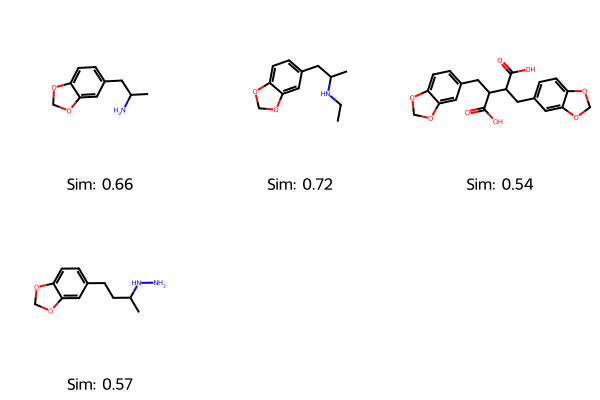

#2


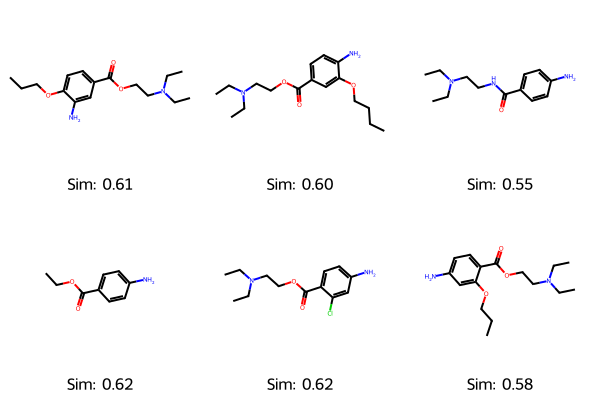

#3


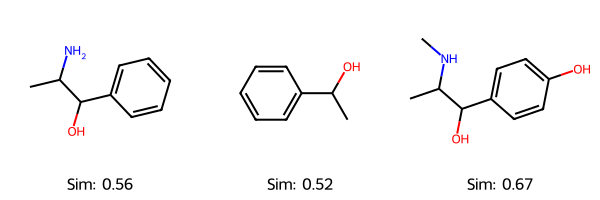

#4


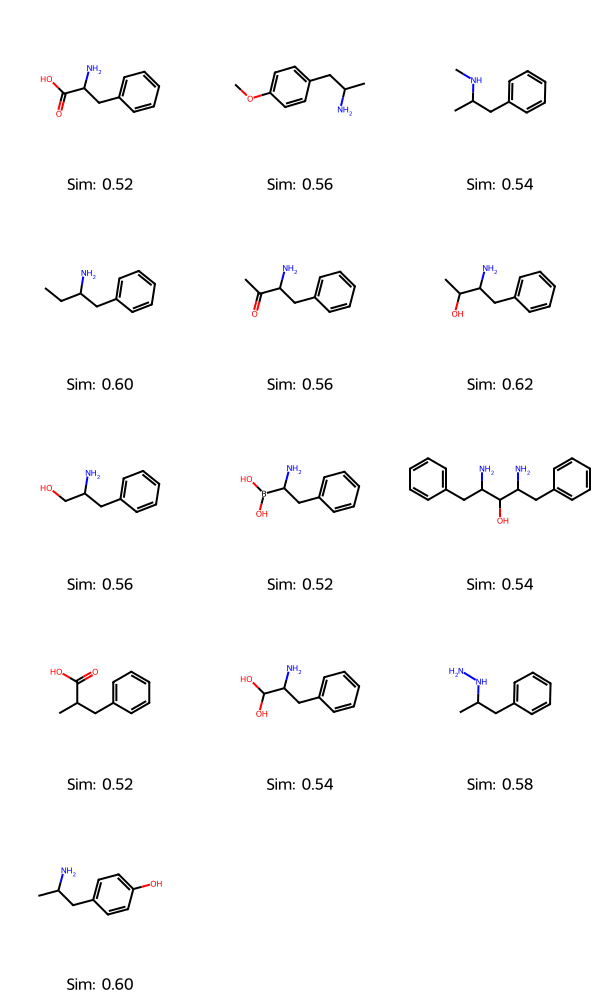

#5


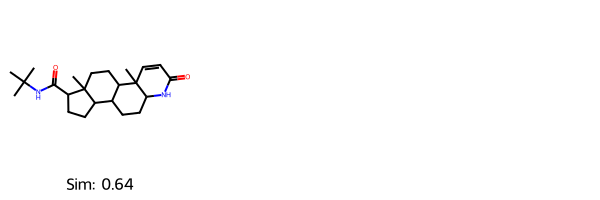

#6


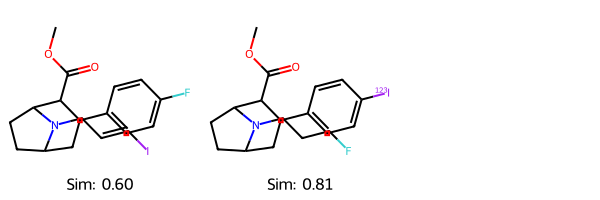

#7


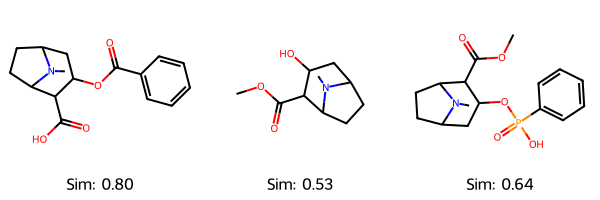

#8


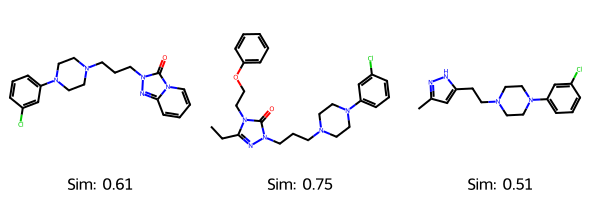

Smazáno 35 molekul


In [8]:
from rdkit import DataStructs
from rdkit.Chem import Draw
import numpy as np

def get_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)

# Fingerprinty
inhibitor_fps = [get_fp(smi) for smi in inhibitor_smiles_set]
inactive_fps_series = inactives_all['smiles'].apply(get_fp)
inactive_fps = inactive_fps_series.tolist()
inactive_indices = inactive_fps_series.index.tolist()

indices_to_remove = set()

# Projdi inhibitory a najdi podobné inactives
for i, i_fp in enumerate(inhibitor_fps):
    sims = DataStructs.BulkTanimotoSimilarity(i_fp, inactive_fps)
    
    # Filtruj nad 0.5
    mask = np.array(sims) > 0.5
    similar_local_idx = np.where(mask)[0]
    
    closest_mols = [Chem.MolFromSmiles(inactives_all.iloc[idx]['smiles']) for idx in similar_local_idx]
    similar_sims = np.array(sims)[mask]
    print(f"#{i+1}")
    display(Draw.MolsToGridImage(closest_mols, legends=[f"Sim: {s:.2f}" for s in similar_sims]))
    
    for idx in similar_local_idx:
        indices_to_remove.add(inactive_indices[idx])

# Smaž podobné molekuly
inactives = inactives_all.drop(index=list(indices_to_remove)).reset_index(drop=True)

if 'fp' in inactives_all.columns:
    inactives_all = inactives_all.drop(columns=['fp'])

print(f"Smazáno {len(inactives_all) - len(inactives)} molekul")

In [9]:
display(inhibitor_fps)

## Pročištění datasetu `inhibitors_st`
* Ověřím, že `known_inhibitors` jsou mezi `inhibitors_st`, případně přidám.

In [10]:
# ověření přítomností v inhibitors 
is_included = inhibitors_st['smiles'].isin(inhibitor_smiles_set)
new_data = []
for name, smi in known_inhibitors.items():
    can_smi = Chem.MolToSmiles(Chem.MolFromSmiles(smi))
    if can_smi in inhibitors_st['smiles'].values:
        print(f"{name} v `inhibitors_st` je")
    else:
        print(f"{name} je škoada nemít. přidáme.")
        new_row = {'smiles': can_smi} 
        new_data.append(new_row)
new_rows_df = pd.DataFrame(new_data)
inhibitors_st = pd.concat([inhibitors_st, new_rows_df], ignore_index=True)

procaine v `inhibitors_st` je
dutasteride je škoada nemít. přidáme.
midomafetamine v `inhibitors_st` je
dextroamphetamine v `inhibitors_st` je
ioflupane v `inhibitors_st` je
etoperidone je škoada nemít. přidáme.
pseudoephedrine je škoada nemít. přidáme.
cocaine v `inhibitors_st` je


* Míra inhibice je udávána v různých jednotkách. 

In [11]:
display(inhibitors_st[['Standard Type', 'Standard Units', 'Value']])

,Standard Type,Standard Units,Value
0,IC50,nM,107.6
1,IC50,nM,109.0
2,IC50,nM,1.4
3,IC50,nM,2.0
4,IC50,nM,5.8
...,...,...,...
5433,IC50,nM,123.0
5434,Inhibition,%,2.0
5435,NaN,NaN,NaN
5436,NaN,NaN,NaN


In [12]:
print("Používané Standard Units")
print(inhibitors_st["Standard Units"].unique())

Používané Standard Units
<StringArray>
['nM', '%', nan, 'ug.mL-1', 'uM']
Length: 5, dtype: str


* Prohlédnu si distribuci IC50 hodnot v nanomolární škále.
* Podívám se, kolik je inhibitorů s IC50 pod 500 nM.  

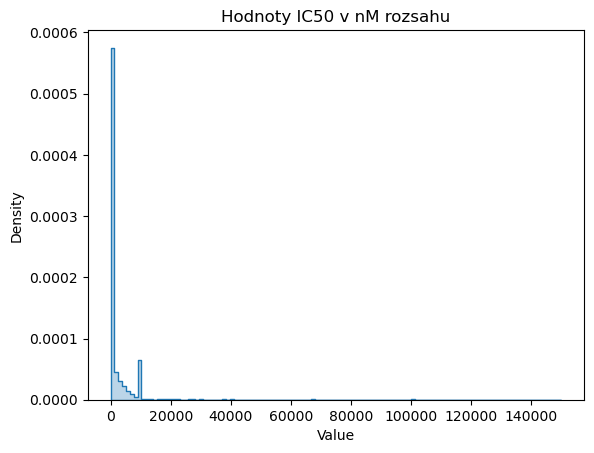

Inhibitorů s IC50 pod 500 nM je 2214.


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(inhibitors_st[inhibitors_st["Standard Units"] == "nM"]["Value"], label='nM',
             stat="density", element="step", alpha=0.3)
plt.title("Hodnoty IC50 v nM rozsahu")
plt.show()

_ =len(inhibitors_st[(inhibitors_st['Standard Units'] == 'nM') & (inhibitors_st['Value'] < 500)
      & (inhibitors_st['Standard Relation'] != ">")])
print(f"Inhibitorů s IC50 pod 500 nM je {_}.")

* Podívám se na mikromolární inhibitory. 

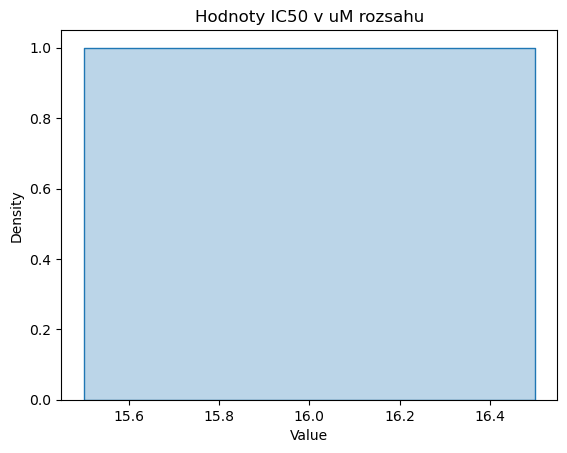

Inhibitorů s IC50 pod 0.5 uM je 0.


In [188]:
sns.histplot(inhibitors_st[inhibitors_st["Standard Units"] == "uM"]["Value"], label='uM',
             stat="density", element="step", alpha=0.3)
plt.title("Hodnoty IC50 v uM rozsahu")
plt.show()

_ =len(inhibitors_st[(inhibitors_st['Standard Units'] == 'uM') & (inhibitors_st['Value'] < 0.500)])
print(f"Inhibitorů s IC50 pod 0.5 uM je {_}.")

* Inhibice v procentech. 

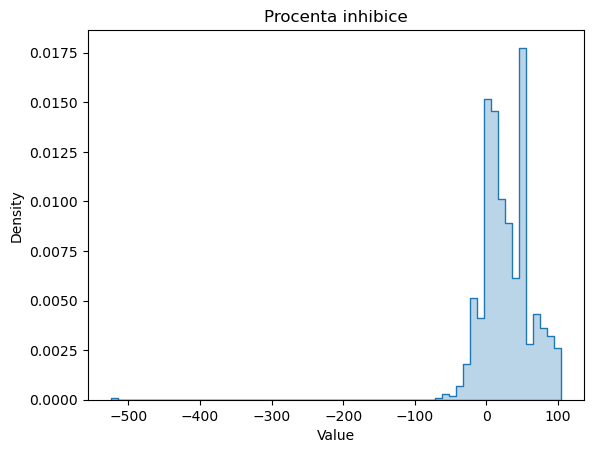

In [15]:
sns.histplot(inhibitors_st[inhibitors_st["Standard Units"] == "%"]["Value"], label='uM',
             stat="density", element="step", alpha=0.3)
plt.title("Procenta inhibice")
plt.show()

* Inhibice v hmotnostní koncentraci. 

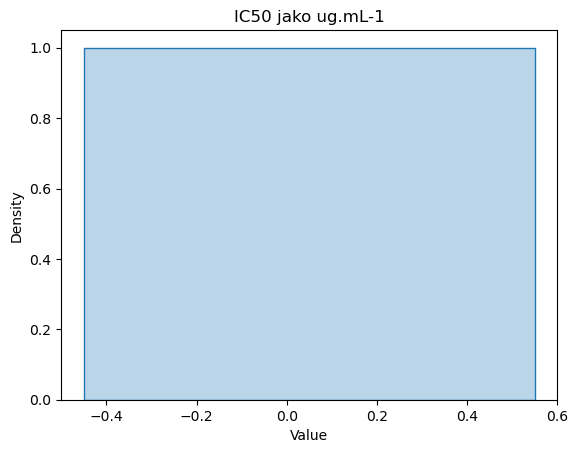

Počet látek s IC50 jako ug.mL-1inhibitor:
1


In [16]:
sns.histplot(inhibitors_st[inhibitors_st["Standard Units"] == "ug.mL-1"]["Value"], label='',
             stat="density", element="step", alpha=0.3)
plt.title("IC50 jako ug.mL-1")
plt.show()
print("Počet látek s IC50 jako ug.mL-1inhibitor:")
print(len(inhibitors_st[inhibitors_st["Standard Units"] == "ug.mL-1"]["Value"]))

#### Pozorování 
* V `inhibitors_st` je molekul s IC50 pod 500 nM celkem 2214.
* Přidám k nim inhibitory s vyšším procentem inhibice než 70. 
* K těmto molekulám přidám látky, které mají vysokou Tanimotovu podobnost s approved `known_inhibitors`. 

In [17]:
inhibitors_refined = inhibitors_st[(inhibitors_st['Standard Units'] == 'nM') & (inhibitors_st['Value'] < 500)
      & (~inhibitors_st['Standard Relation'].isin(["<=", "<"]))][["smiles"]]

print(len(inhibitors_refined))

2214


* Nyní vytvořím `inhibitors_cand`, který bude obsahovat `inhibitors`, které nejsou v `inhibitors_refined` a nemají ve sloupci "Standard Units" hodnoty "nM", "uM".

In [18]:
inhibitors_cand = inhibitors_st[~inhibitors_st["smiles"].isin(inhibitors_refined["smiles"])]
# vyhodím vysoké IC50, co už jsem zkoumal výš
inhibitors_cand = inhibitors_cand[~inhibitors_cand["Standard Units"].isin(["nM", "uM"])][["smiles"]]

display(inhibitors_cand)
print(f"Kandidátů na zařazení je {len(inhibitors_cand)}.")

,smiles
9,Fc1ccc(C(OCCN2CCN(CCCc3ccccc3)CC2)c2ccc(F)cc2)cc1
18,c1ccc(CC2CCN(CCCn3nnnc3-c3cccc4ccccc34)CC2)cc1
20,CSc1sc(C(=N)N)cc1S(=O)(=O)c1cccc(-c2c(C)cccc2N...
29,CNCC(O)CCN1c2ccccc2N(c2ccc(F)c(F)c2)S1(=O)=O
36,CC(=O)N1CCC(N(C)C(=O)NC2CCC(c3cc(F)cc(F)c3)CC2...
...,...
5432,Cn1nccc1C1(CNC(=O)c2ccc(F)c(F)c2-c2ccc(C(F)(F)...
5434,O=C(C(Cc1cccc(C(F)(F)F)c1)NS(=O)(=O)c1cc(F)c2c...
5435,CC12C=CC(=O)NC1CCC1C2CCC2(C)C(C(=O)Nc3cc(C(F)(...
5436,CCc1nn(CCCN2CCN(c3cccc(Cl)c3)CC2)c(=O)n1CC


Kandidátů na zařazení je 2030.


In [19]:
pridat_procenta = inhibitors_st[
    (inhibitors_st["Standard Units"] == "%") &
    (~inhibitors_st["Standard Relation"].isin(["<=", "<"])) &
    (inhibitors_st["Value"] > 70)
][["smiles"]]

pridat_procenta

,smiles
49,CNCCC(Oc1ccccc1OC)c1ccccc1
50,Clc1ccc(C(CC2CNC2)Oc2ccccc2)cc1Cl
204,Cc1nnc(-c2ccc(N3CCC(Oc4cc(F)ccc4Cl)CC3)nn2)o1
207,COc1ccc(F)c(-c2ccc3c(c2)CCC3Oc2cccc(C(C3CC3)C(...
214,CCCCCCCOc1ccc(NC(=O)Oc2cccc(N3CCNCC3)c2)cc1
...,...
5085,N=C(N)NCCCCCNc1noc(Cc2c[nH]c3cc(Br)ccc23)n1
5091,Cc1sc2ccccc2c1C1C=CN=CN1
5212,Cc1c(P(=S)(c2ccccc2)c2ccccc2)n2ccccc2[n+]1CC=C...
5218,CC(NCCCc1cccc(C(F)(F)F)c1)c1cccc2ccccc12


In [20]:
_ = len(inhibitors_refined)
inhibitors_refined = pd.concat([inhibitors_refined, pridat_procenta], ignore_index=True)
print(f"{len(inhibitors_refined) - (_)} > 0")

112 > 0


In [21]:
# podočtu morganovy fingerprinty 
inhibitors_cand["mfp"] = inhibitors_cand["smiles"].apply(
    lambda smiles: Chem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles), 2, nBits=2048)
)
display(inhibitors_cand.columns)

Index(['smiles', 'mfp'], dtype='str')

#1: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.
#2: Počet příbuzných molekul je 5.


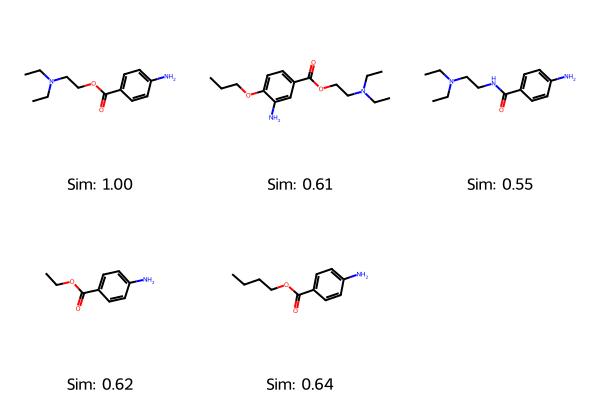

#3: Počet příbuzných molekul je 1.


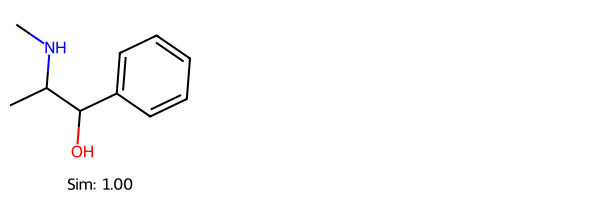

#4: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.
#5: Počet příbuzných molekul je 2.


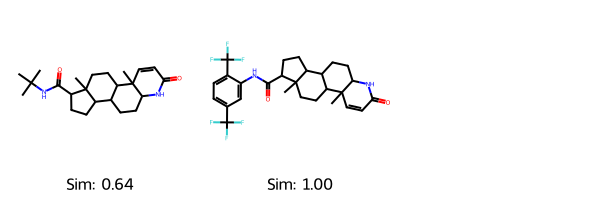

#6: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.
#7: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.
#8: Počet příbuzných molekul je 3.


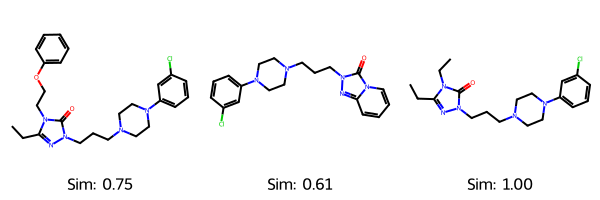

In [22]:
# inhibitor_fps obsahují morganovy fingerprinty `known_inhibitors`
pridat = pd.DataFrame()

# Projdi inhibitory a najdi podobné inactives
for i, i_fp in enumerate(inhibitor_fps):
    sims = DataStructs.BulkTanimotoSimilarity(i_fp, inhibitors_cand["mfp"].tolist())
    
    # Filtruj nad 0.5
    mask = np.array(sims) > 0.5
    similar_local_idx = np.where(mask)[0]
    
    closest_mols = [Chem.MolFromSmiles(inhibitors_cand.iloc[idx]['smiles']) for idx in similar_local_idx]
    similar_sims = np.array(sims)[mask]
    print(f"#{i+1}: Počet příbuzných molekul je {sum(mask)}.")
    try:
        display(Draw.MolsToGridImage(closest_mols, legends=[f"Sim: {s:.2f}" for s in similar_sims]))
    except:
        print(f"Není co zobrazit, nejbližších je {len(closest_mols)}.")
    # přidej, pokud ještě není
    new_rows = inhibitors_cand.iloc[similar_local_idx]
    pridat = pd.concat([pridat, new_rows], ignore_index=True)


In [23]:
print(f"Počet k přidání: ", len(pridat))

pridat

Počet k přidání:  11


,smiles,mfp
0,CCN(CC)CCOC(=O)c1ccc(N)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
1,CCCOc1ccc(C(=O)OCCN(CC)CC)cc1N,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,CCN(CC)CCNC(=O)c1ccc(N)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
3,CCOC(=O)c1ccc(N)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCCCOC(=O)c1ccc(N)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
5,CNC(C)C(O)c1ccccc1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,CC(C)(C)NC(=O)C1CCC2C3CCC4NC(=O)C=CC4(C)C3CCC12C,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
7,CC12C=CC(=O)NC1CCC1C2CCC2(C)C(C(=O)Nc3cc(C(F)(...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
8,CCc1nn(CCCN2CCN(c3cccc(Cl)c3)CC2)c(=O)n1CCOc1c...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
9,O=c1n(CCCN2CCN(c3cccc(Cl)c3)CC2)nc2ccccn12,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


* Čekal jsem víc...
* Krom samotných `known_inhibitors`, podívám se na více informací o těchto látkách.

In [24]:
inhibitors_st[inhibitors_st["smiles"].isin(pridat["smiles"])][["Molecule Name", 
                                                         "Standard Type", "Value", "Standard Units", 
                                                        "Standard Text Value"]]

,Molecule Name,Standard Type,Value,Standard Units,Standard Text Value
1215,FINASTERIDE,IC50,NaN,NaN,Not Active
1420,PROCAINE,IC50,NaN,NaN,Not Active
1447,PROPARACAINE,Ki,NaN,NaN,Not Active
1675,PROCAINAMIDE,IC50,NaN,NaN,Not Active
1809,NEFAZODONE HYDROCHLORIDE,Inhibition,78.66,%,NaN
1844,TRAZODONE,IC50,NaN,NaN,Not Active
1958,BENZOCAINE,IC50,NaN,NaN,Not Active
4303,BUTAMBEN,IC50,NaN,NaN,Not Active
5435,NaN,NaN,NaN,NaN,NaN
5436,NaN,NaN,NaN,NaN,NaN


* Je zajímavé, že např. procaine je v Chembl veden jako neaktivní, ale DrugBank nikoliv.
* Budu se držet konvence Chembl. 

In [25]:
_ = len(inhibitors_refined)
inhibitors_refined = pd.concat([inhibitors_refined, 
                                inhibitors_st[(inhibitors_st["smiles"].isin(pridat["smiles"])) & (inhibitors_st["Standard Text Value"]!="Not Active")][['smiles']]               
                               ], ignore_index=True)
print(f"{len(inhibitors_refined) - (_)} > 0")

4 > 0


In [26]:
inhibitors = inhibitors_refined.drop_duplicates().copy()
matching_st = inhibitors_st[inhibitors_st["smiles"].isin(inhibitors["smiles"])]
inhibitors = inhibitors.merge(matching_st, on="smiles", how="left")

inhibitors

,smiles,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,COC1NN=C(C[S+]([O-])C(c2ccccc2)c2ccccc2)S1,CHEMBL4085703,NaN,NaN,346.48,0.0,3.10,4b,COC1NN=C(C[S+]([O-])C(c2ccccc2)c2ccccc2)S1,IC50,...,CHEMBL4028886,1.0,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,107.60
1,Cc1cc(=O)[nH]c(C[S+]([O-])C(c2ccccc2)c2ccccc2)n1,CHEMBL4092312,NaN,NaN,338.43,0.0,3.53,7g,Cc1cc(O)nc(C[S+]([O-])C(c2ccccc2)c2ccccc2)n1,IC50,...,CHEMBL4028886,1.0,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,109.00
2,[O-][S+](Cc1cccs1)C(c1ccccc1)c1ccccc1,CHEMBL4084700,NaN,NaN,312.46,0.0,4.79,11b,[O-][S+](Cc1cccs1)C(c1ccccc1)c1ccccc1,IC50,...,CHEMBL4028886,1.0,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,1.40
3,Cc1ccc(C(c2ccccc2)[S+]([O-])Cc2cccs2)cc1,CHEMBL4064788,NaN,NaN,326.49,1.0,5.09,11d,Cc1ccc(C(c2ccccc2)[S+]([O-])Cc2cccs2)cc1,IC50,...,CHEMBL4028886,1.0,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,2.00
4,Cc1ccc(C(c2ccc(C)cc2)[S+]([O-])Cc2cccs2)cc1,CHEMBL4065787,NaN,NaN,340.51,1.0,5.40,11f,Cc1ccc(C(c2ccc(C)cc2)[S+]([O-])Cc2cccs2)cc1,IC50,...,CHEMBL4028886,1.0,Scientific Literature,J Med Chem,2017.0,CHEMBL3307715,NaN,NaN,NaN,5.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,CC(NCCCc1cccc(C(F)(F)F)c1)c1cccc2ccccc12,CHEMBL1200776,CINACALCET HYDROCHLORIDE,4.0,393.88,1.0,6.14,EUB0000437aCl,C[C@@H](NCCCc1cccc(C(F)(F)F)c1)c1cccc2ccccc12.Cl,Inhibition,...,CHEMBL5442219,55.0,EUbOPEN Chemogenomic Library,NaN,2024.0,NaN,Compound concentration = 0.00001 M | Radioliga...,NaN,NaN,70.43
2325,COc1ccc2ncc(F)c(CCC3(O)COC4C(NCc5cc6c(cn5)OCCO...,CHEMBL4788651,NaN,NaN,498.51,0.0,1.56,6,COc1ccc2ncc(F)c(CC[C@@]3(O)CO[C@@H]4[C@@H](NCc...,Inhibition,...,CHEMBL4765317,1.0,Scientific Literature,Eur J Med Chem,2020.0,NaN,Dose = 100.0 microM | TIME = 3.0 hr,INHIBITOR,NaN,96.00
2326,CC12C=CC(=O)NC1CCC1C2CCC2(C)C(C(=O)Nc3cc(C(F)(...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2327,CCc1nn(CCCN2CCN(c3cccc(Cl)c3)CC2)c(=O)n1CC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Import knihovny ke screeningu 
* Prohledám knihovnu `Enamine_Hit_Locator_Library_100K` od Enamine (https://enamine.net/compound-libraries/libraries-catalog).

In [27]:
enamine_orig = pd.read_csv("Enamine_Hit_Locator_Library_100K_Set_plated_100160cmpds_20260301.csv")
display(enamine_orig.head())
print(f"Délka enamine: {len(enamine_orig)} \n")

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,Cl.NCC(C1=CNC=2C=CC=CC12)C=3C=CC=CC3Cl,Z57988914,307.217,270.757,3.574,-4.800,2,1,41.81,3,https://real.enamine.net/public-enum-files/Z57...
1,CC=1C=CC=C(C1)CC2=NOC(=N2)C3=CC(C#N)=CN3,Z1683335414,264.283,264.283,2.997,-3.569,1,3,78.50,3,https://real.enamine.net/public-enum-files/Z16...
2,CC=1C=CC=2N=C(SC2C1)C=3C=CC(=CC3)NC(=O)CSC4=NC...,Z56838658,408.500,408.500,3.136,-7.440,2,4,83.45,5,https://real.enamine.net/public-enum-files/Z56...
3,CC(C)C1=NOC(=N1)C=2C=CC(=CC2)NC(=O)N3CCOCC3,Z1117060619,316.356,316.356,1.715,-3.748,1,4,80.49,5,https://real.enamine.net/public-enum-files/Z11...
4,FC(F)(F)C=1C=CC=C(C1)CSC2=NN=C(O2)C3=CC=CN3,Z98928949,325.311,325.311,3.004,-5.770,1,2,54.71,5,https://real.enamine.net/public-enum-files/Z98...


Délka enamine: 100160 



### Standardizace `enamine`

In [38]:
enamine = enamine_orig.copy()
failed_count = 0

enamine['purified'] = enamine['SMILES'].apply(purify_smiles)

print(f"Posralo se {failed_count}.")

# odstranění duplikátů a nan 
enamine = enamine.dropna(subset=['purified'])
enamine = enamine.drop_duplicates(subset=['purified'], keep='first')


# Cleanup
enamine['smiles'] = enamine['purified']
enamine = enamine.drop(columns=['purified']).reset_index(drop=True)

print(f"`enamine_orig` má délku {len(enamine_orig)}")
print(f"`enamine` má délku {len(enamine)}")

Posralo se 0.
`enamine_orig` má délku 100160
`enamine` má délku 99843


In [28]:
#enamine.to_csv("enamine.csv", index=False)
enamine = pd.read_csv("enamine.csv")

* Nyní mám připraveny vyčištěné sety
    * `inhibitors` se známými inhibitory DAT,
    * `inactives` s předpokládanými neaktivními látkami,
    * `enamine` s knihovnou ke screeningu.
* Sety analyzuji.  
--- 

# Analýza pomocí deskritportů  

## Porovnání ChEMBL a výpočtu RDKit 
* Vypočtu logP a rull-of-five compliance podle RDKitu a vypočítám korelaci.  

In [29]:
from rdkit.Chem import rdMolDescriptors
def more_analysis(df):
    """
    Ze smiles dopočte MW, LogP, HBD, HBA, počet aromatických kruhů, TPSA
    
    Vrátí počet veličin nevyhovující RO5
    """
    def compute_properties(smi):
        mol = Chem.MolFromSmiles(smi)
        
        nevyhovuje = 0 
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = rdMolDescriptors.CalcNumLipinskiHBD(mol)
        hba = rdMolDescriptors.CalcNumLipinskiHBA(mol)
        TPSA = rdescriptors.CalcTPSA(mol) 
        ring_count = len(Chem.GetSSSR(mol))
        rotatable = Chem.CalcNumRotatableBonds(mol)
        HAC = mol.GetNumHeavyAtoms()
        
        # lipinski 
        if mw >= 500:
            nevyhovuje = nevyhovuje + 1
        if logp >= 5:
            nevyhovuje = nevyhovuje + 1
        if hbd > 5:
            nevyhovuje = nevyhovuje + 1
        if hba > 10:
            nevyhovuje = nevyhovuje + 1
        
        return mw, logp, nevyhovuje, TPSA, HAC, rotatable, ring_count

    results = df['smiles'].apply(compute_properties)
    
    # Unpack the results into the DataFrame
    df[['mw_comp', 'logp_comp', 'RO5_comp', 
        'TPSA_comp', 'HAC_comp', 'rotatable_comp', 'ring_count_comp',      
       ]] = pd.DataFrame(results.tolist(), index=df.index)
    return df

In [30]:
inhibitors_compare = more_analysis(inhibitors)

inhibitors_compare.head()
# print(len(inhibitors_compare))

,smiles,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,...,Action Type,Standard Text Value,Value,mw_comp,logp_comp,RO5_comp,TPSA_comp,HAC_comp,rotatable_comp,ring_count_comp
0,COC1NN=C(C[S+]([O-])C(c2ccccc2)c2ccccc2)S1,CHEMBL4085703,NaN,NaN,346.48,0.0,3.10,4b,COC1NN=C(C[S+]([O-])C(c2ccccc2)c2ccccc2)S1,IC50,...,NaN,NaN,107.6,346.477,3.10460,0,56.68,23,6,3
1,Cc1cc(=O)[nH]c(C[S+]([O-])C(c2ccccc2)c2ccccc2)n1,CHEMBL4092312,NaN,NaN,338.43,0.0,3.53,7g,Cc1cc(O)nc(C[S+]([O-])C(c2ccccc2)c2ccccc2)n1,IC50,...,NaN,NaN,109.0,338.432,3.11662,0,68.81,24,5,3
2,[O-][S+](Cc1cccs1)C(c1ccccc1)c1ccccc1,CHEMBL4084700,NaN,NaN,312.46,0.0,4.79,11b,[O-][S+](Cc1cccs1)C(c1ccccc1)c1ccccc1,IC50,...,NaN,NaN,1.4,312.459,4.78640,0,23.06,21,5,3
3,Cc1ccc(C(c2ccccc2)[S+]([O-])Cc2cccs2)cc1,CHEMBL4064788,NaN,NaN,326.49,1.0,5.09,11d,Cc1ccc(C(c2ccccc2)[S+]([O-])Cc2cccs2)cc1,IC50,...,NaN,NaN,2.0,326.486,5.09482,1,23.06,22,5,3
4,Cc1ccc(C(c2ccc(C)cc2)[S+]([O-])Cc2cccs2)cc1,CHEMBL4065787,NaN,NaN,340.51,1.0,5.40,11f,Cc1ccc(C(c2ccc(C)cc2)[S+]([O-])Cc2cccs2)cc1,IC50,...,NaN,NaN,5.8,340.513,5.40324,1,23.06,23,5,3


In [31]:
# Vypočtu korelace 
pairs = [('Molecular Weight', 'mw_comp'), ('AlogP', 'logp_comp'), ('#RO5 Violations', 'RO5_comp')]
for c1, c2 in pairs:
    print(f"Korelace uvedené {c1} a vypočtené {c2} je {inhibitors_compare[c1].corr(inhibitors_compare[c2]):.4f}.")

Korelace uvedené Molecular Weight a vypočtené mw_comp je 0.9871.
Korelace uvedené AlogP a vypočtené logp_comp je 0.9993.
Korelace uvedené #RO5 Violations a vypočtené RO5_comp je 0.9778.


#### Pozorování 
* Rozdíly jsou minimální, způsobené budou pravděpodobně způsobeny standardizací, zejména neutralizací nábojů, a rozdělením solí. 

## Porovnání 
* Srovnejme datasety pomocí histogramů:
    * AlogP
    * Počet cyklů
    * HAC
    * TPSA 

In [32]:
# Dopočítám deskriptory 
inactives_compare = more_analysis(inactives) # tady je to duplicitní
enamine_compare = more_analysis(enamine)

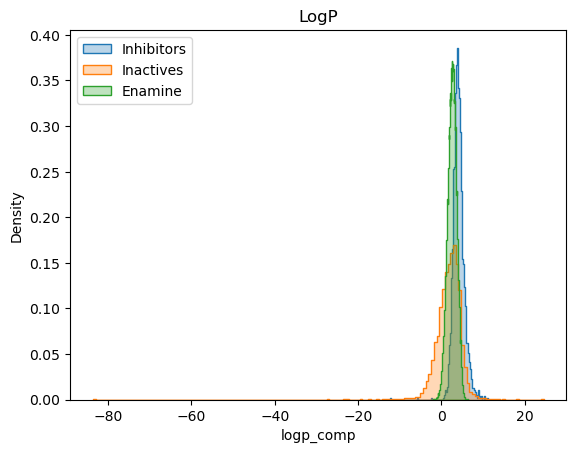

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.title("LogP")
sns.histplot(inhibitors_compare['logp_comp'], label='Inhibitors',
             stat="density", element="step", alpha=0.3)

sns.histplot(inactives_compare['logp_comp'], label='Inactives', 
             stat="density", element="step", alpha=0.3)

sns.histplot(enamine_compare['logp_comp'], label='Enamine', 
             stat="density", element="step", alpha=0.3)

plt.legend()
plt.show()

#### Pozorování 
* Distribuce logP jsou unimodální s podobným maximem pro všechy sety.
* Set `inactives` má větší varianci a dlouhý chvost k hydrofilním molekulámhydrofilní chvost.
* Distribuce jsou pravděpodobně posunuté k hydrofilním hodnotám vlivem neutralizace nábojů a eliminace solí.

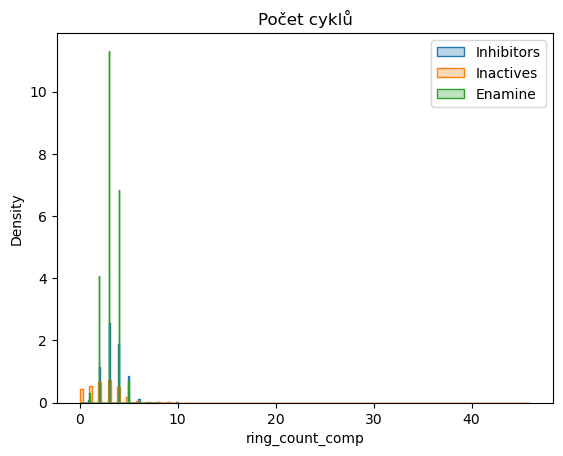

In [34]:
plt.title("Počet cyklů")
sns.histplot(inhibitors_compare['ring_count_comp'], label='Inhibitors',
             stat="density", element="step", alpha=0.3)

sns.histplot(inactives_compare['ring_count_comp'], label='Inactives', 
             stat="density", element="step", alpha=0.3)

sns.histplot(enamine_compare['ring_count_comp'], label='Enamine', 
             stat="density", element="step", alpha=0.3)

plt.legend()
plt.show()

#### Pozorování 
* Set `inactives` má opět širší distribuci.
* Distribuce mají podobný modus, `inactives` obsahuje látky s menším počtem cyklů, ale distribuce zároveň chvostuje k velmi vysokým hodnotám. 

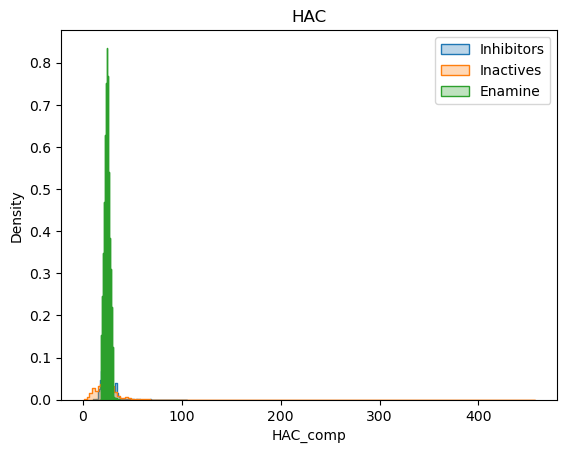

In [35]:
plt.title("HAC")
sns.histplot(inhibitors_compare['HAC_comp'], label='Inhibitors',
             stat="density", element="step", alpha=0.3)

sns.histplot(inactives_compare['HAC_comp'], label='Inactives', 
             stat="density", element="step", alpha=0.3)

sns.histplot(enamine_compare['HAC_comp'], label='Enamine', 
             stat="density", element="step", alpha=0.3)

plt.legend()
plt.show()

#### Pozorování 
* Předchozí pozorování je platné i pro počet těžkých atomů.  

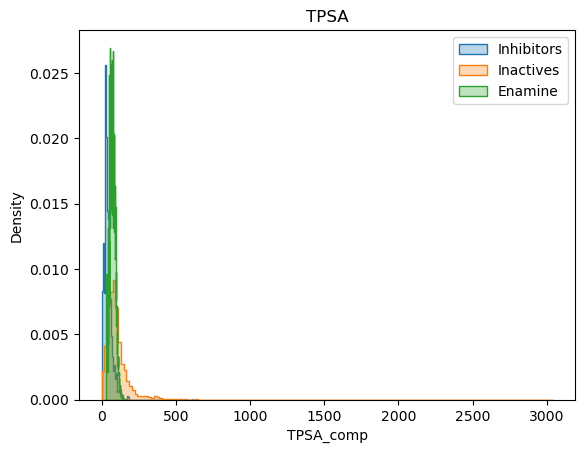

In [36]:
plt.title("TPSA")
sns.histplot(inhibitors_compare['TPSA_comp'], label='Inhibitors',
             stat="density", element="step", alpha=0.3)

sns.histplot(inactives_compare['TPSA_comp'], label='Inactives', 
             stat="density", element="step", alpha=0.3)

sns.histplot(enamine_compare['TPSA_comp'], label='Enamine', 
             stat="density", element="step", alpha=0.3)

plt.legend()
plt.show()

#### Pozorování 
* Distribuce velikostí povrchů u `inhibitors` má maximum posunuté k menší hodnotě.
* `inactives` má opět nejširší distribuci.   

# Vizualizace datasetů pomocí redukce dimenze 
* Zkusím UMAP a MACCS keys. Díky nim mohou být klastry interpretovatelné na základě přítomnosti daných funkčních skupin.
* Na stejných datech zkusím i PCA, kde by přítamonost daých funkčních skupin měla být spojitelná s vysvětlenou variancí.  

In [48]:
from rdkit.Chem import MACCSkeys
import umap

def get_maccs(smi):
    return list(MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(smi)).ToBitString())

# Generate strings 
m_inh = pd.DataFrame([get_maccs(s) for s in inhibitors['smiles']]).astype(int)
m_ina = pd.DataFrame([get_maccs(s) for s in inactives['smiles']]).astype(int)
m_ena = pd.DataFrame([get_maccs(s) for s in enamine['smiles']]).astype(int)

# Combine for UMAP
m_inh['set'], m_ena['set'], m_ina['set'], = 'inhibitor','enamine' ,'inactive', 
combined = pd.concat([m_inh, m_ena, m_ina,], ignore_index=True)

# UMAP
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(combined.drop(columns=['set']))

/tmp/ipykernel_1876/1849075083.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  m_inh['set'], m_ena['set'], m_ina['set'], = 'inhibitor','enamine' ,'inactive',


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_1876/2624606587.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined['umap1'], combined['umap2'] = embedding[:, 0], embedding[:, 1]


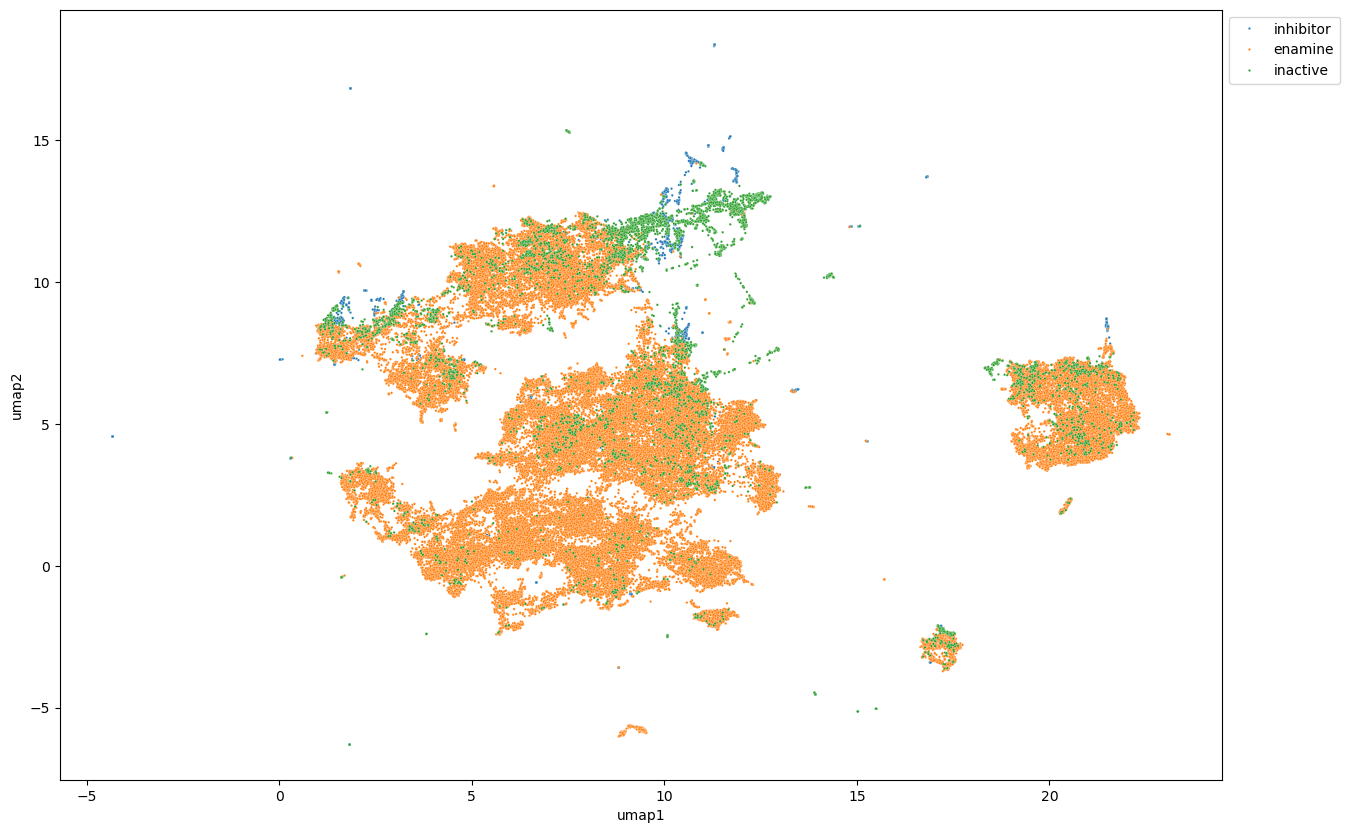

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))

combined['umap1'], combined['umap2'] = embedding[:, 0], embedding[:, 1]
sns.scatterplot(data=combined, x='umap1', y='umap2', hue='set', s=3, alpha=1)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

/tmp/ipykernel_1876/998098775.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined['pca1'], combined['pca2'] = coords[:, 0], coords[:, 1]


<Axes: xlabel='pca1', ylabel='pca2'>

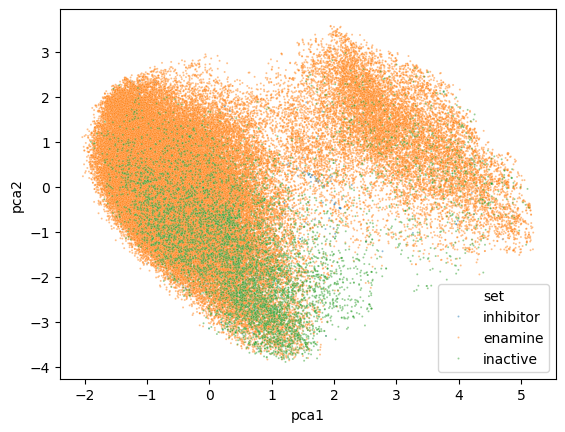

In [50]:
from sklearn.decomposition import PCA

# Use the same 'combined' bitframe from the MACCS step
pca = PCA(n_components=2)
coords = pca.fit_transform(combined.drop(columns=['set', 'umap1', 'umap2']))

combined['pca1'], combined['pca2'] = coords[:, 0], coords[:, 1]
sns.scatterplot(data=combined, x='pca1', y='pca2', hue='set', s=2, alpha=0.5)

#### Pozorování 
* Tyto metody spolu s MACCS keys nedokázaly vzájemně oddělit jednotlivé datasety.
* Zkusím `MorganFingerprint` a UMAP lépe vyladit.

In [37]:
def get_morgan(smi):
    mol = Chem.MolFromSmiles(smi)
    return list(Chem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))

# Generate 
df_inh = pd.DataFrame([get_morgan(s) for s in inhibitors['smiles']]).assign(set='inhibitor')
df_ina = pd.DataFrame([get_morgan(s) for s in inactives['smiles']]).assign(set='inactive')
df_ena = pd.DataFrame([get_morgan(s) for s in enamine['smiles']]).assign(set='enamine')

# Combine
combined_mfp = pd.concat([df_inh, df_ina, df_ena], ignore_index=True)

In [39]:
# UMAP 

reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, metric='jaccard', random_state=42)
embedding = reducer.fit_transform(combined_mfp.drop(columns=['set']))

/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/pynndescent/pynndescent_.py:1241: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/umap/umap_.py:128: UserWarning: A few of your vertices were disconnected from the manifold.  This shouldn't cause problems.
Disconnection_distance = 1 has removed 25 edges.
It has only fully disconnected 1 vertices.
Use umap.utils.disconnected_vertices() to identify them.
  warn(


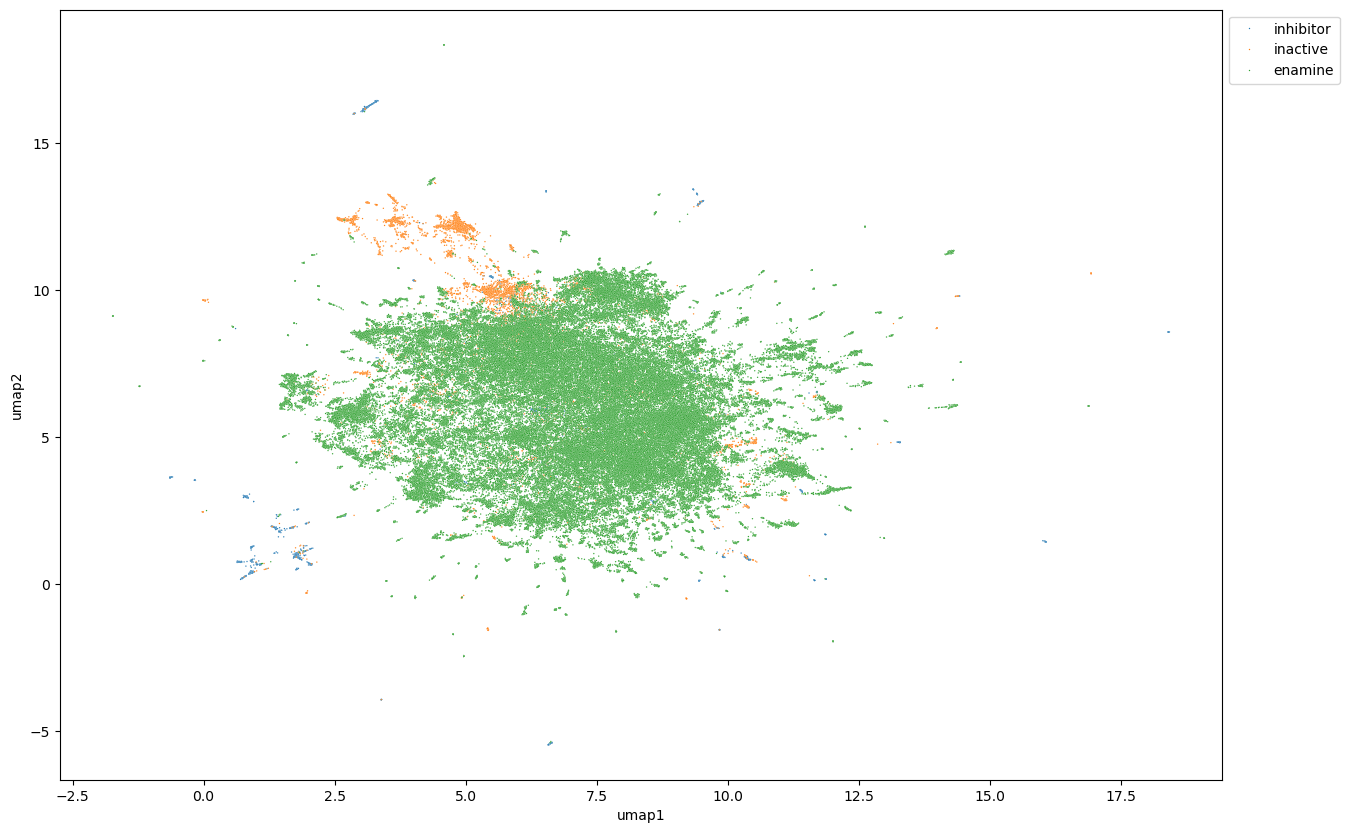

In [59]:
plt.figure(figsize=(15, 10))

combined_mfp['umap1'], combined_mfp['umap2'] = embedding[:, 0], embedding[:, 1]
sns.scatterplot(data=combined_mfp, x='umap1', y='umap2', hue='set', s=1, alpha=1)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

#### Pozorování 
* Ani s Morganovými fingerprinty se nepovedlo datasety dobře oddělit, a to jak pro různé úrovně lokálnosti zobrazením (`n_neighbors`), tak vzdáleností mezi body (`min_dist`).
* To, že se datasety překrývají, může být pro trénování modelů výhodou, protože cílový set `enamine` je srovnatelný s trénovacím setem, model na něm bude platný.  

# Analýza substruktur a scaffoldů
* Pomocí `MurckoScaffold` a `GetSubstructMatch` najdu:
  * Scaffold methylekgoninu.
  * Ester kyseliny benzoové.
  * Methylovaný terciální amin.
* Porovnám relativní četnosti ve všech datasetech. 

In [40]:
# napočítejme scaffoldy 
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffolds(smiles_col):
    def process_smiles(s):
        try:
            mol = Chem.MolFromSmiles(s)
            if mol is None:  # Invalid SMILES
                print("neni smiles")
                return None
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            generic_scaffold = MurckoScaffold.MakeScaffoldGeneric(scaffold)
            return generic_scaffold
        except Exception as e:
            mol = Chem.MolFromSmiles(s)
            print(f"Nešlo z toho udělat scaffold pro {display(mol)}: {e}")
            return None
    return smiles_col.apply(process_smiles)

* Dopočet scaffoldů.
* Nekonvertovatelné molekuly jsou zobrazeny. 

In [41]:
inhibitors_scaf = get_scaffolds(inhibitors["smiles"])

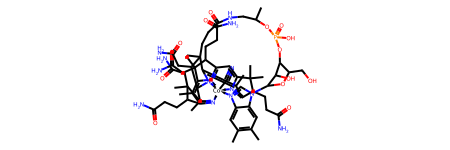

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 3 C, 5, is greater than permitted


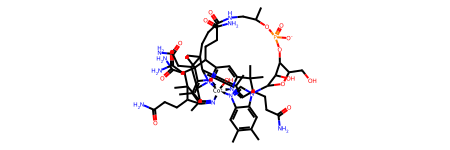

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 3 C, 5, is greater than permitted


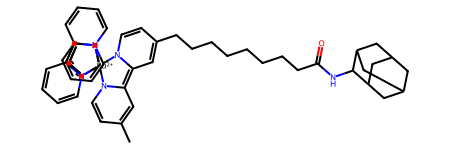

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 30 C, 6, is greater than permitted


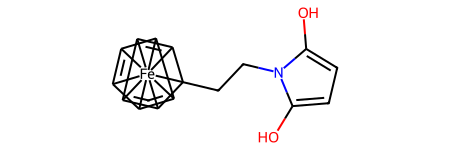

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 12 C, 10, is greater than permitted


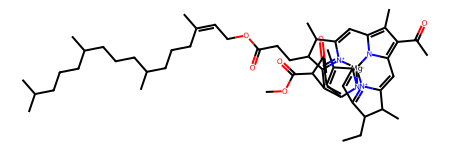

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 10 C greater than permitted


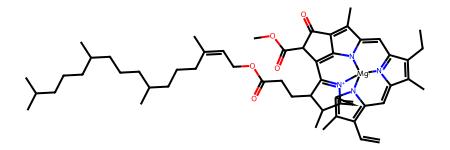

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 11 C greater than permitted


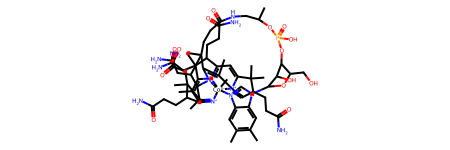

Nešlo z toho udělat scaffold pro None: Explicit valence for atom # 39 C, 5, is greater than permitted


In [42]:
inactives_scaf = get_scaffolds(inactives["smiles"])
enamine_scaf = get_scaffolds(enamine["smiles"])

* Namátková kontrola několika scaffoldů. 

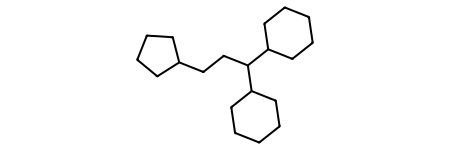

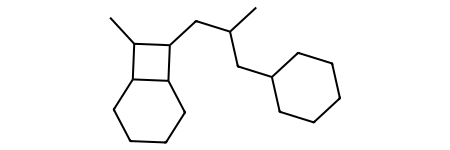

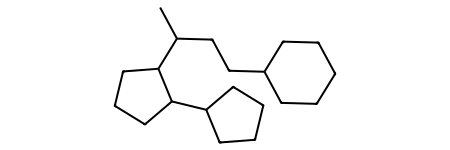

In [43]:
display(inhibitors_scaf[0])
display(inactives_scaf[1000])
display(enamine_scaf[10000])

## Relativní zastoupení methyelkgoniu  

In [155]:
# funkce na výpočet 

def has_substructure(scaffold_mol, query_mol):
    if scaffold_mol is None:
        return False
    return scaffold_mol.HasSubstructMatch(query_mol)

methylekgonine


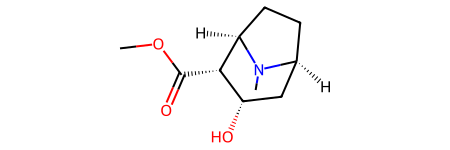

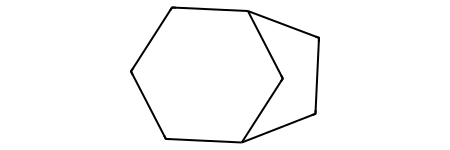

Kokain


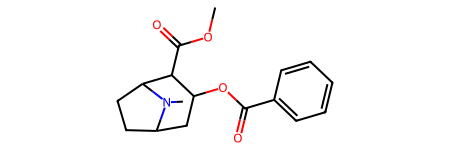

In [186]:
print("methylekgonine")
display(Chem.MolFromSmiles("CN1[C@H]2CC[C@@H]1[C@H]([C@H](C2)O)C(=O)OC"))
methylekgonine = pd.Series(purify_smiles("CN1[C@H]2CC[C@@H]1[C@H]([C@H](C2)O)C(=O)OC"))
methylekgonine_scaf = get_scaffolds(methylekgonine)
display(methylekgonine_scaf[0])

print("Kokain")
koks = Chem.MolFromSmiles(pd.Series(purify_smiles("CN1[C@H]2CC[C@@H]1[C@H]([C@H](C2)OC(=O)C3=CC=CC=C3)C(=O)OC"))[0])

display(koks)

In [187]:
from collections import Counter
query_mol = methylekgonine_scaf[0]

sets = {"inhibitors": inhibitors_scaf, "inactives": inactives_scaf, "enamine": enamine_scaf}
for i in sets.keys(): 
    matches = sets[i].apply(lambda x: has_substructure(x, query_mol))
    frequency = matches.sum()
    total = len(matches)
    percentage = (frequency / total) * 100
    print(f"V {i} je scaffold methyelkgoninu zastoupen z {percentage:.2f} %.")

V inhibitors je scaffold methyelkgoninu zastoupen z 17.48 %.


V inactives je scaffold methyelkgoninu zastoupen z 0.57 %.


V enamine je scaffold methyelkgoninu zastoupen z 0.36 %.


#### Pozorování
* Scaffold methylekgoninu, tedy alkaloidu tvořícího jádro kokainu, má mnohem vyšší zastoupení mezi inhibitory DAT.  

## Zastoupení esteru kyseliny benzoové 
* Na účinku kokainu se podílí reziduum kyseliny benzoové.
* Porovnám jeho relativní zastoupení. 

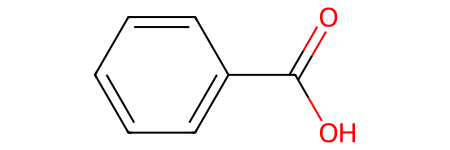

In [46]:
benzoate = pd.Series(purify_smiles("C1=CC=C(C=C1)C(=O)O"))
query_mol = Chem.MolFromSmiles(benzoate[0])
display(query_mol)

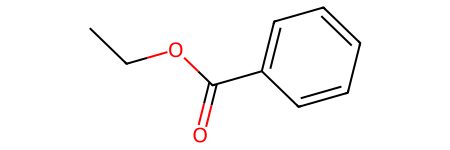

Je tam?
True
Je benzoát v benzenu?


False

In [47]:
# pokus: pozná kód benzoát v ethylbenzoátu? 
ethylbenzoat = Chem.MolFromSmiles('CCOC(=O)C1=CC=CC=C1')
display(ethylbenzoat)
print("Je tam?")
print(has_substructure(ethylbenzoat, query_mol))

print("Je benzoát v benzenu?")
has_substructure(Chem.MolFromSmiles("cccccc"), query_mol)

In [48]:
sets = {"inhibitors": inhibitors['smiles'], "inactives": inactives['smiles'], "enamine": enamine['smiles']}
for i in sets.keys(): 
    matches = sets[i].apply(lambda x: has_substructure(Chem.MolFromSmiles(x), query_mol))
    frequency = matches.sum()
    total = len(matches)
    percentage = (frequency / total) * 100
    print(f"V {i} je benzoát zastoupen z {percentage:.2f} %.")

V inhibitors je benzoát zastoupen z 0.56 %.


V inactives je benzoát zastoupen z 3.75 %.


V enamine je benzoát zastoupen z 1.91 %.


## Zastoupení terciálního aminu 

In [49]:
methylamine = pd.Series(purify_smiles("CN"))
query_mol = Chem.MolFromSmiles(methylamine[0])

In [50]:
# pár pokusů 
print("Je alkylamin v")  
print("kokainu?")
print(has_substructure(koks, query_mol))

print("ethylbenzoátu?")
print(has_substructure(ethylbenzoat, query_mol))

print("pyridinu?")
print(has_substructure(Chem.MolFromSmiles("c1ccncc1"), query_mol))

print("dopaminu?")
print(has_substructure(Chem.MolFromSmiles("C1=CC(=C(C=C1CCN)O)O"), query_mol))

print("amomiaku?")
print(has_substructure(Chem.MolFromSmiles("NH3"), query_mol))

Je alkylamin v
kokainu?
True
ethylbenzoátu?
False
pyridinu?
False
dopaminu?
True
amomiaku?
False


In [51]:
sets = {"inhibitors": inhibitors['smiles'], "inactives": inactives['smiles'], "enamine": enamine['smiles']}
for i in sets.keys(): 
    matches = sets[i].apply(lambda x: has_substructure(Chem.MolFromSmiles(x), query_mol))
    frequency = matches.sum()
    total = len(matches)
    percentage = (frequency / total) * 100
    print(f"V {i} je alkylamin zastoupen z {percentage:.2f} %.")

V inhibitors je alkylamin zastoupen z 90.73 %.


V inactives je alkylamin zastoupen z 75.30 %.


V enamine je alkylamin zastoupen z 98.30 %.


#### Pozorování 
* Zatímco benzoát není pro inhibitory DAT charakteristický, alkylamin je v inhibitorech zastoupenější oproti neaktivním látkám.

# Modely pro predikce aktivity  

In [52]:
print("Data k dspozici:")
print(f"inhibitors: {len(inhibitors)}")
print(f"inactives: {len(inactives)}")

Data k dspozici:
inhibitors: 2329
inactives: 6717


* Překvapivě mají obě množiny nenulový průnik. Smažu ho v obou množinách. 

In [53]:
# průnik 
intersection = set(inhibitors['smiles']).intersection(set(inactives['smiles']))
print(f"Velikost průniku: {len(intersection)}")

# průnik se maže v obou 
inhibitors_fin = inhibitors[~inhibitors['smiles'].isin(intersection)]
inactives_fin = inactives[~inactives['smiles'].isin(intersection)]

intersection = set(inhibitors_fin['smiles']).intersection(set(inactives_fin['smiles']))
print(f"Velikost průniku po opravě: {len(intersection)}")

Velikost průniku: 82
Velikost průniku po opravě: 0


## Oddělení testovacích dat
* Pomocí `MaxMinPicker` vyberu z celé množiny dat k trénování reprezentativní testovací set.
* Testovací set bude nerovnoměrný, skládající se z 70 positives. 

In [54]:
from rdkit import DataStructs
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

def maxmin_sample(df, n_picks, seed=42):
    mols = [Chem.MolFromSmiles(s) for s in df["smiles"]]
    fps = [Chem.GetMorganFingerprintAsBitVect(m, 2, 2048) for m in mols]
    
    # Funkce pro výpočet vzdálenosti (1 - Tanimoto)
    def dist_ij(i, j):
        return 1 - DataStructs.TanimotoSimilarity(fps[i], fps[j])
    
    picker = MaxMinPicker()
    picks = list(picker.LazyPick(dist_ij, len(fps), n_picks, seed=seed))
    return df.iloc[picks]

# Provedení výběru
test_inhibitors = maxmin_sample(inhibitors_fin, 70)[["smiles"]]
test_inactives = maxmin_sample(inactives_fin, 700)[["smiles"]]

* `SciKit` vyžaduje trénovací data jako jednu množinu.
* Vytvořím proto funkci, která:
    * Spojí a aktivní a neaktivní látky,
    * přidá labells,
    * promíchá vzniklý set.
* Pomocí této funkce vytvořím testovací set. 

In [55]:
def combine_and_label(actives_df, inactives_df):
    s1 = actives_df[['smiles']].assign(active=1)
    s2 = inactives_df[['smiles']].assign(active=0)
    return pd.concat([s1, s2], ignore_index=True).sample(frac=1).reset_index(drop=True)


# test set 
test = combine_and_label(test_inhibitors, test_inactives)
display(test)

,smiles,active
0,Nc1[nH]nc2nnc(-c3c(-c4ccccc4)nn4ccccc34)cc12,0
1,O=CCCSC(=O)CCS,0
2,O=C(CN1CC(O)C(NC(=O)c2ccc(Cl)s2)C1)Nc1ccc(-n2c...,0
3,COC1C(OC(=O)NC(=O)CCl)CCC2(CO2)C1C1(C)OC1CC=C(C)C,0
4,CC1=C(N2CC2)C(=O)C(CO)=C(N2CC2)C1=O,0
...,...,...
765,CNC1CC2OC(C)(C1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2...,0
766,CC1CCN(C(=O)CC#N)CC1N(C)c1ncnc2[nH]ccc12,0
767,[O]=[V]1([OH])[O][V](=[O])([OH])[O][V](=[O])([...,0
768,O=C1c2cc3c(cc2OC2CCCN12)OCCO3,0


* Vytvořím trénovací set. 

In [56]:
all_merged = combine_and_label(inhibitors_fin, inactives_fin)
train = all_merged[~all_merged['smiles'].isin(test['smiles'])]
print(f"len(all_merged)({len(all_merged)}) - len(train)({len(train)}) = {len(all_merged) - len(train)} ")
print("skutečná délka test: ",len(test)) 

len(all_merged)(8882) - len(train)(8112) = 770 
skutečná délka test:  770


In [57]:
print("Počet duplicitních SMILES v all_merged:", all_merged.duplicated(subset=['smiles']).sum())

Počet duplicitních SMILES v all_merged: 0


## Výběr podmnožiny `enamine` 
* Vyberu si podmnožinu enaminu, která je nejpříbuznější trénovacím datům.
* Příbuznost je vyhodnocena následujícím způsobem:
    * Výpočet vzálenosti každé molekuly z `enamine` ke každé z molekul z trénovací množiny.
    * Zprůměrovnání pěti nejvyšších podobností.
    * Jako podobné jsou považovány molekuly s průměrnou podobností přes 0.25. 

In [58]:
def get_knn_similarity_df(target_df, train_df, k=5):
    train_fps = [get_fp(smi) for smi in train_df["smiles"]]
    target_fps = [get_fp(smi) for smi in target_df["smiles"]]
    
    avg_similarities = []

    for tfp in target_fps:
        if tfp is None: # Ošetření, pokud by se nepovedlo MolFromSmiles
            avg_similarities.append(None)
            continue
            
        sims = DataStructs.BulkTanimotoSimilarity(tfp, train_fps)
        # vezmi k-nejpodobnějších  
        top_k_sims = sorted(sims, reverse=True)[:k]
        # zprůměruj a ulož 
        avg_similarities.append(np.mean(top_k_sims))
        
    return pd.DataFrame({
        "smiles": target_df["smiles"].values,
        "avg_similarity": avg_similarities
    })


In [117]:
target_proto = get_knn_similarity_df(enamine, train, k=5)

In [59]:
# uložim si, ať nepřepočítávám 
#target_proto.to_csv("target_proto.csv", index=False)
target_proto = pd.read_csv("target_proto.csv")

* Zobrazím distribuci podobností.

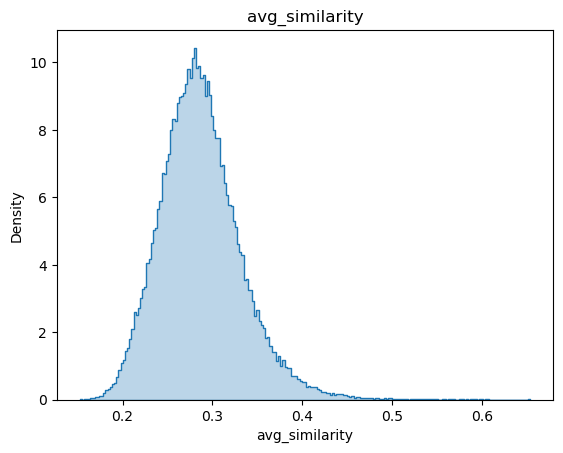

In [60]:
sns.histplot(target_proto["avg_similarity"], label='nM',
             stat="density", element="step", alpha=0.3)
plt.title("avg_similarity")
plt.show()

In [61]:
# Vyfiltrování řádků s průměrnou podobností nad 0.25
target = target_proto[target_proto['avg_similarity'] >= 0.25][['smiles']].copy()

# Reset indexu, zamíchání 
target = target.sample(frac=1).reset_index(drop=True)

print(f"Původní počet: {len(target_proto)}")
print(f"Vyfiltrovaný počet: {len(target)}")

Původní počet: 99843
Vyfiltrovaný počet: 79705


## Trénování Random Forrest
* Tránování provádím na Morganových fingerprintech. 
* Pomocí `GridSearch` naladím:
    * Maximální hloubku, 
    * délku fingerprintu, 
    * Maximální počet bitů, které má každý strom k dispozici. 

In [62]:
# Příprava trénovací sady
X_train = train[['smiles']]
Y_train = train['active']

# Příprava testovací sady
X_test = test[['smiles']]
Y_test = test['active']

print(f"Trénovací data: {X_train.shape[0]} vzorků")
print(f"Testovací data: {X_test.shape[0]} vzorků")

Trénovací data: 8112 vzorků
Testovací data: 770 vzorků


In [63]:
print(f"Podíl positives {sum(Y_train)/len(Y_train)}")

Podíl positives 0.26836785009861935


In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

# encoding
class MoleculeEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, radius=2, nBits=2048):
        self.radius = radius
        self.nBits = nBits
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        fps = []
        for s in X:
            mol = Chem.MolFromSmiles(s)
            fp = Chem.GetMorganFingerprintAsBitVect(mol, self.radius, nBits=self.nBits)
            arr = np.zeros((1,))
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
        return np.array(fps)

# Pipeline
pipe = Pipeline([
    ('encoder', MoleculeEncoder()),
    ('rf', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
])

# lAdění hyperparametrů 
param_grid = {
    'encoder__radius': [2, 3, 4],
    'encoder__nBits': [512, 1024, 2048],
    'rf__n_estimators': [500],
    'rf__max_depth': [10, 20, None],
    'rf__max_features': ['sqrt', 0.1, None] # 0.1 znamená 10 % všech bitů
}

# 'average_precision'
grid = GridSearchCV(
    pipe, 
    param_grid, 
    scoring='average_precision', 
    cv=5, 
    verbose=0
)

# Nafituji finální model 
grid.fit(X_train['smiles'], Y_train)

import joblib
# Save the trained model
joblib.dump(grid, 'grid_model.pkl')

print(f"Nejlepší parametry: {grid.best_params_}")
print(f"Nejlepší skóre (AUC-PR): {grid.best_score_:.4f}")

Nejlepší parametry: {'encoder__nBits': 2048, 'encoder__radius': 2, 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 500}
Nejlepší skóre (AUC-PR): 0.9873


* Zkusím k Morganovým fingerprintům přidat ještě několik fyzikálně chemických deskriptorů.  

In [65]:
class HybridEncoder:
    def __init__(self, radius=2, nBits=2048):
        self.radius = radius
        self.nBits = nBits

    def get_features(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            return np.zeros(self.nBits + 7) # Fallback
        
        # Morgan Fingerprint 
        fp = Chem.GetMorganFingerprintAsBitVect(mol, self.radius, nBits=self.nBits)
        fp_array = np.zeros((0,))
        DataStructs.ConvertToNumpyArray(fp, fp_array)
        
        # Fyzikálně-chemické deskriptory 
        phys_features = [
            Descriptors.MolWt(mol),          # MW
            Descriptors.MolLogP(mol),        # logP
            Descriptors.TPSA(mol),           # TPSA
            Descriptors.NumHDonors(mol),     # HBD
            Descriptors.NumHAcceptors(mol),   # HBA
            Descriptors.NumRotatableBonds(mol), # Flexibilita
            Descriptors.RingCount(mol)       # Scaffold character
        ]
        
        return np.concatenate([fp_array, phys_features])

    def transform_df(self, df):
        return np.array([self.get_features(s) for s in df['smiles']])

# Inicializace hybridního encoderu
encoder = HybridEncoder(radius=2, nBits=2048)

# Příprava dat 
print("Generuji hybridní příznaky...")
X_train_final = encoder.transform_df(X_train)
X_target_final = encoder.transform_df(target)

# Finální Model
# Používáme parametry z minulého GridSearch
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Trénuji finální model...")
final_model.fit(X_train_final, Y_train)

Generuji hybridní příznaky...


Trénuji finální model...


['final_model.pkl']

In [80]:
# Save the trained model
joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

* Vyhodnotím na základě 5-fold cross-validace, metrikou je AUC. 

In [67]:
from sklearn.model_selection import cross_val_score

print("5-fold cross val")
cv_scores = cross_val_score(
    final_model, 
    X_train_final, 
    Y_train, 
    cv=5, 
    scoring='average_precision',
    n_jobs=-1
)

# Výsledky
print("5-fold CV (AUC-PR)")
print(f"Průměrné skóre: {cv_scores.mean():.4f}")

5-fold cross val


5-fold CV (AUC-PR)
Průměrné skóre: 0.9877


* Vracím se k původnímu modelu na Morganových fingerprintech, přidané sloupce nebyly benefitem. 

* Vyhodnotím model na testovacích datech pomocí
    * recall, procento ze 70 aktivních látek, které najdu v 70 nejpravděpodobnějších hitech podle modelu, 
    * enrichment, tedy recall normované zastoupením activních molekul. 

In [68]:
Y_test_proba_active = grid.predict_proba(X_test['smiles'])[:,1]

In [69]:
test_result = pd.concat([test, pd.DataFrame(Y_test_proba_active, columns=['proba'])], axis=1)

In [70]:
display(test_result.sort_values(by='proba', ascending=False).head(20))
test_recal = test_result.sort_values(by='proba', ascending=False).head(Y_test.sum())['active'].sum() / Y_test.sum()
print(f"test_recal = {test_recal}")
test_enrichment = test_recal / (sum(Y_test)/len(Y_test))
print(f"Test enrichment: {test_enrichment}")

,smiles,active,proba
740,Fc1cc2c(cc1-c1ccc(C(F)(F)F)nn1)CNCC2c1ccc(Cl)c...,1,0.996
386,COc1ccc2c(c1)CN(C)CC2c1ccc2sccc2c1,1,0.972
510,C=C1CN2C3CCC2C1C(c1ccc(Cl)cc1)C3,1,0.964
555,Fc1cccc(Oc2cc(F)c(F)cc2N2CCCC3(CCCNC3)C2)c1,1,0.962
594,CC#CNC(=O)C12CNCCC1(c1ccc(Cl)c(Cl)c1)C2,1,0.958
35,Clc1ccc(Cl)c(OC(c2ccccc2)C2CCNC2)c1Cl,1,0.950
12,Fc1ccc(C23CCN(CC2)Cc2cc(-c4ccc5ncnn5c4)ccc23)c...,1,0.950
243,FC(F)(F)c1cccc(N2CCN(CCCn3nnnc3C(c3ccccc3)c3cc...,1,0.948
292,Cc1cc(C2=C(c3ccc(Cl)c(Cl)c3)CC3CCC2S3)on1,1,0.938
350,CNCCCC1(C)Cc2ccccc2N(c2ccccc2)C1=O,1,0.934


test_recal = 0.6285714285714286
Test enrichment: 6.914285714285714


* Provedu predikci pro targety. 

In [71]:
Y_target_proba_active = grid.predict_proba(target['smiles'])[:,1]

* Vyberu 100 nejlepších. 

In [72]:
target_result = pd.concat([target, pd.DataFrame(Y_target_proba_active, columns=['proba'])], axis=1)
# vyberu 100 nejlepších 
top_targets = target_result.sort_values(by='proba', ascending=False).head(100).reset_index(drop=True)
display(top_targets.head(10))

,smiles,proba
0,CN(C(=O)CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1)C(C1CC1)C...,0.868
1,CC1CN(C(=O)Cc2ccc(Cl)c(Cl)c2)CC(C)N1,0.828
2,O=C(CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1)N1CCC2(CCC2)C1,0.828
3,NC(=O)CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1,0.814
4,CC(C)(CNC(=O)N1CC(CO)C1)c1ccc(Cl)c(Cl)c1,0.814
5,COCC1CCCN(C(=O)NCC(C)(C)c2ccc(Cl)c(Cl)c2)C1,0.812
6,CCN1CC(CN2C(=O)NC(C)(c3ccc(Cl)c(Cl)c3)C2=O)CC1=O,0.810
7,O=C1CC2(CCCC2)C(=O)N1Cc1ccc(Cl)c(Cl)c1,0.800
8,CN(C(=O)C1CCCN(C(=O)c2ccc(Cl)c(Cl)c2)C1)c1ccc(...,0.796
9,Cc1ccccc1CCCN(Cc1cncnc1)C1CCCNCC1,0.792


* Ve 100 nejlpeších látkách identifikuji látky podobné ke schváleným léčivům.
* Podobnost je definována jako Tanimotova podbnost vyšší než 0.2. 

#1: Počet příbuzných molekul je 4.


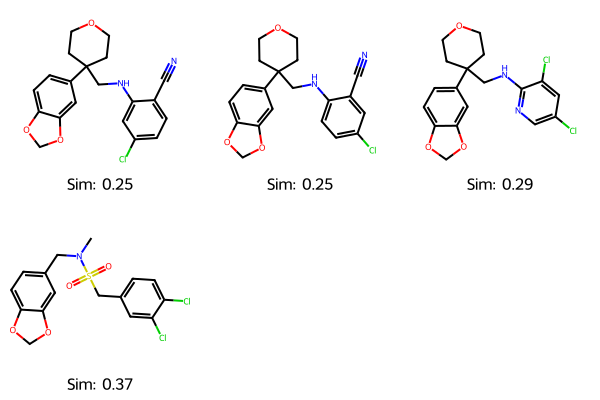

#2: Počet příbuzných molekul je 0.


Není co zobrazit, nejbližších je 0.
#3: Počet příbuzných molekul je 1.


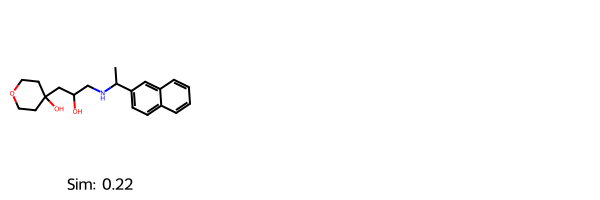

#4: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.
#5: Počet příbuzných molekul je 2.


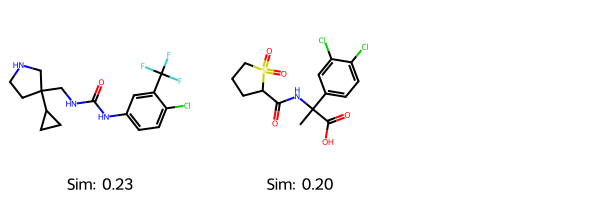

#6: Počet příbuzných molekul je 1.


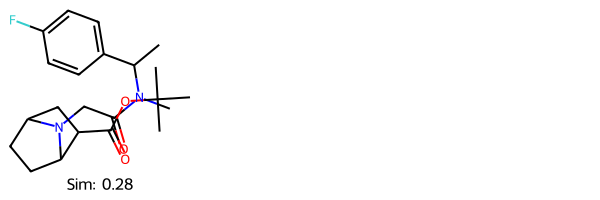

#7: Počet příbuzných molekul je 2.


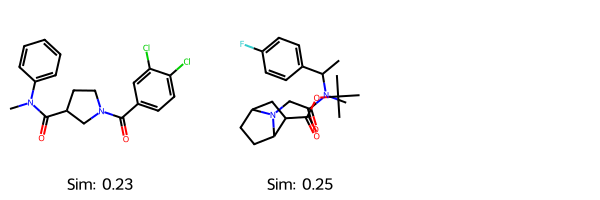

#8: Počet příbuzných molekul je 1.


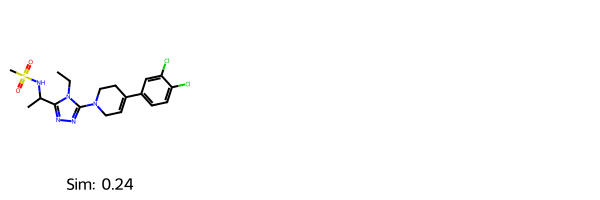

In [73]:
# Projdi top_tagets a najdi podobné k danému léčivu 
for i, i_fp in enumerate(inhibitor_fps): 
    sims = DataStructs.BulkTanimotoSimilarity(i_fp, top_targets['smiles'].apply(get_fp).tolist())
    
    # Filtruj nad 0.2
    mask = np.array(sims) > 0.2
    similar_local_idx = np.where(mask)[0]
    
    closest_mols = [Chem.MolFromSmiles(top_targets.iloc[idx]['smiles']) for idx in similar_local_idx]
    similar_sims = np.array(sims)[mask]
    print(f"#{i+1}: Počet příbuzných molekul je {sum(mask)}.")
    try:
        display(Draw.MolsToGridImage(closest_mols, legends=[f"Sim: {s:.2f}" for s in similar_sims]))
    except:
        print(f"Není co zobrazit, nejbližších je {len(closest_mols)}.")

* Vykreslím 30 molekul s nejvyšší pravděpodobností aktivity. 

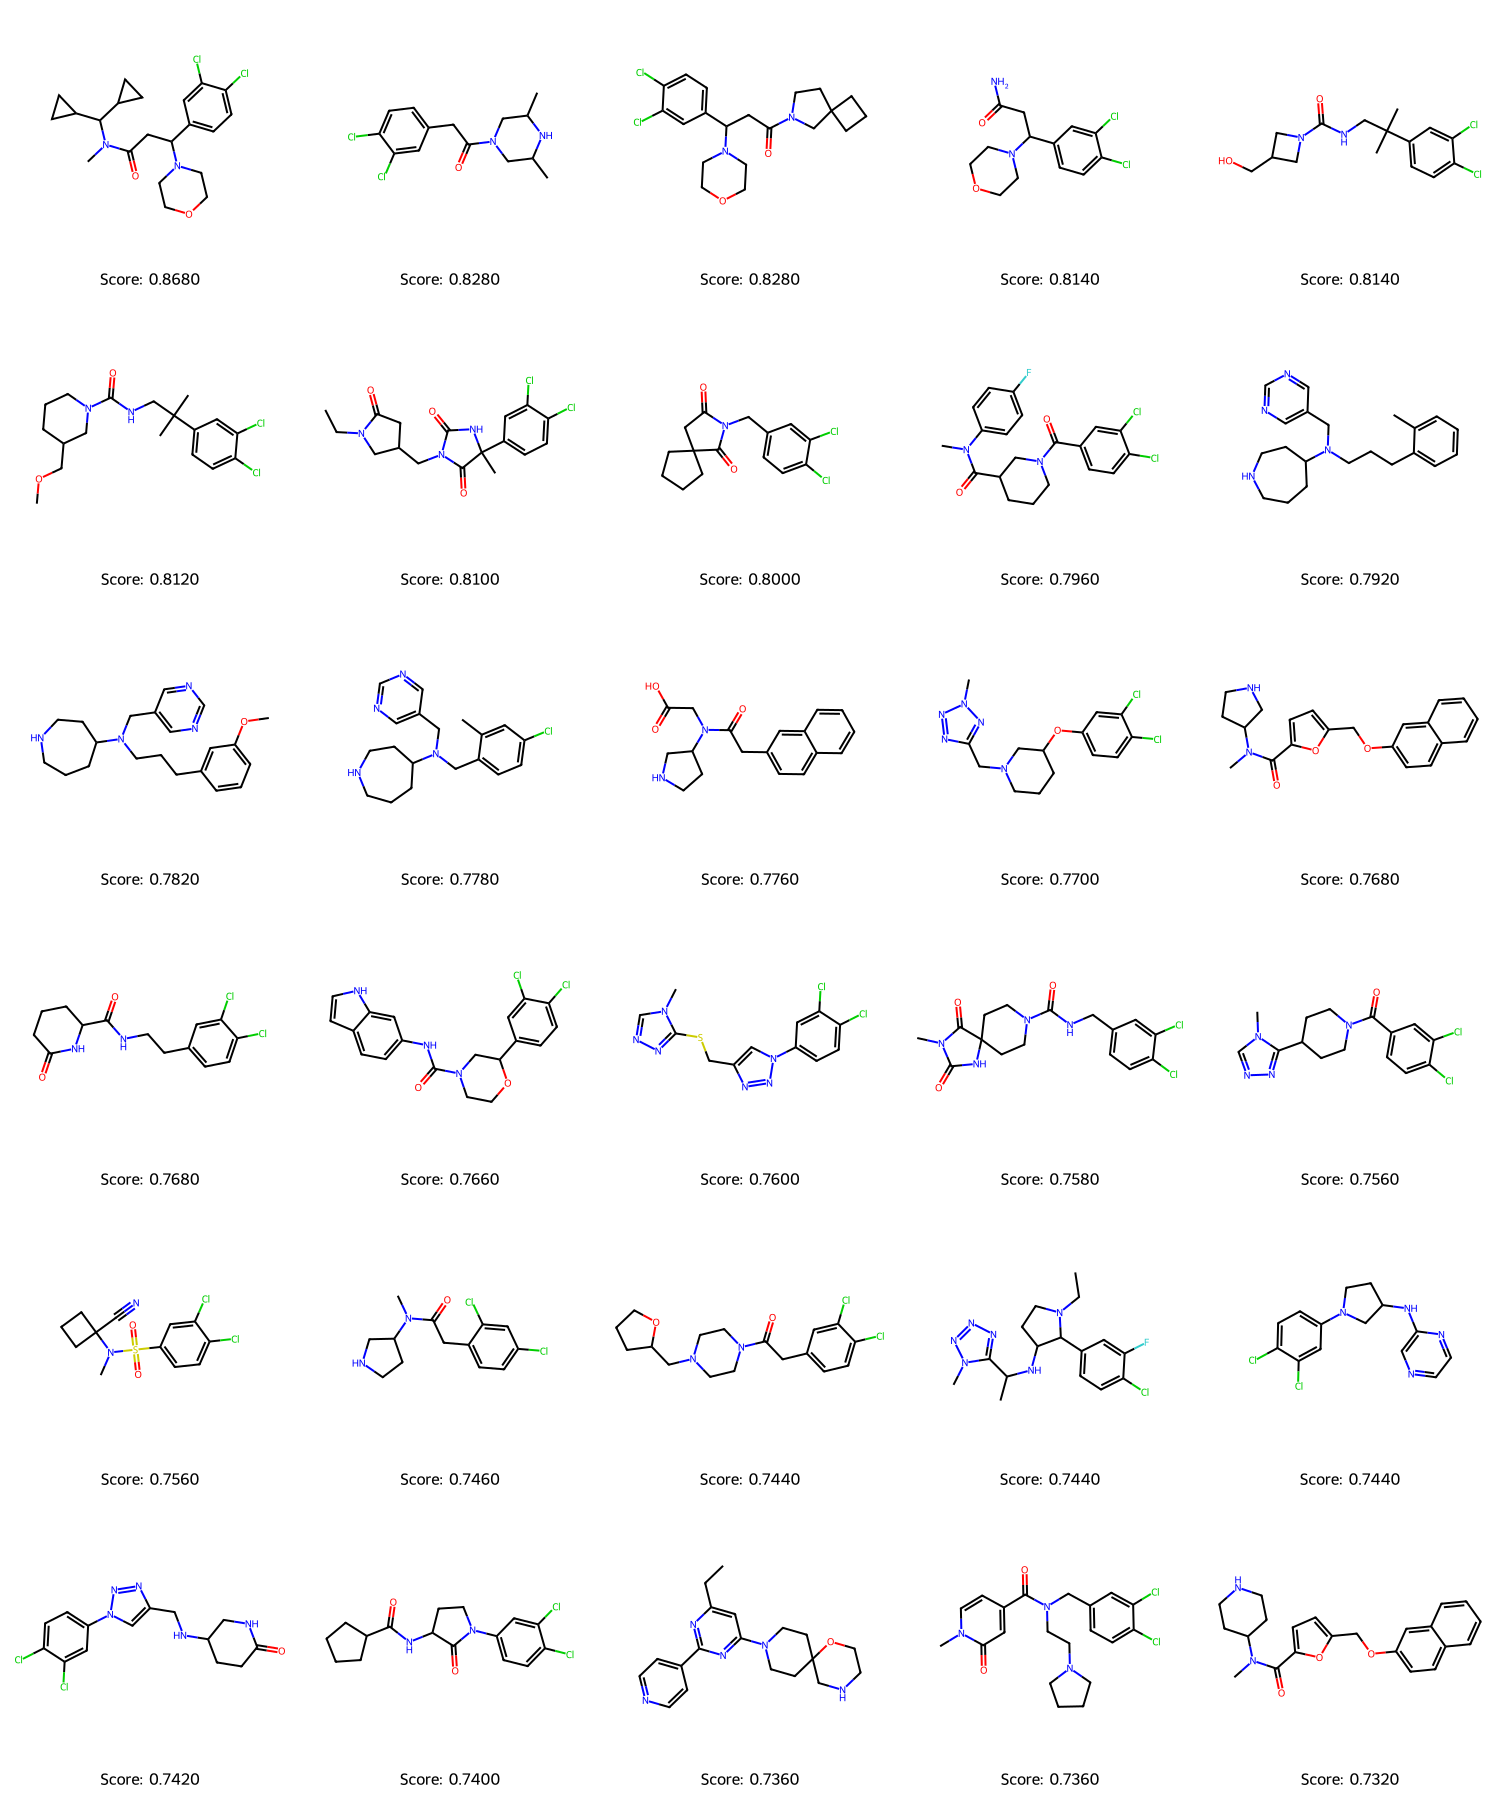

In [74]:
top_30 = top_targets.sort_values(by='proba', ascending=False).head(30)

mols = [Chem.MolFromSmiles(s) for s in top_30['smiles']]
legends = [f"Score: {p:.4f}" for p in top_30['proba']]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

display(img)

## XGboost 
* Optimimalizaci provedu pomocí balíku Optuna.
* Použiji Morganovy fingerprinty o délce 2048, jak bylo optimalizováno pro RF.
* Model vyhodnotím stejně jako RF. 

In [75]:
# předpočítám si fingerprinty 
# použiju encoder výše 
encoder = MoleculeEncoder(radius=2, nBits=2048)
X_train_fps = encoder.transform(X_train["smiles"])
X_test_fps = encoder.transform(X_test["smiles"])
target_fps = encoder.transform(target["smiles"])

X_train_fps

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(8112, 2048))

* Model bude více penalizován za špatné zařazení minoritní třídy, a to v poměru zastoupení aktivních molekul v trénovacím setu.   

In [78]:
scale = (Y_train == 0).sum() / (Y_train == 1).sum() 

scale

np.float64(2.726228755167662)

In [79]:
import optuna
from xgboost import XGBClassifier

def objective(trial):
    # 1. Definice prostoru parametrů k ladění
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        
        # Fixní parametry
        'scale_pos_weight': scale,
        'eval_metric': 'aucpr',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1
    }

    # 2. Vytvoření modelu s navrženými parametry
    model = XGBClassifier(**params)

    # 3. 5-fold Cross-validation
    # Používáme už předpřipravené X_train_fps (matice fingerprintů)
    cv_scores = cross_val_score(
        model, 
        X_train_fps, 
        Y_train, 
        cv=5, 
        scoring='average_precision',
        n_jobs=-1
    )

    # Vracíme průměrné AUC-PR, které chceme maximalizovat
    return cv_scores.mean()

# 4. Vytvoření a spuštění studie
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100) 

print(f"Nejlepší AUC-PR: {study.best_value:.4f}")
print("Nejlepší parametry:")
print(study.best_params)

# 5. Natrénování finálního modelu s nejlepšími parametry
best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=scale, n_jobs=-1, random_state=42)
best_xgb.fit(X_train_fps, Y_train)

[I 2026-05-18 08:02:01,360] A new study created in memory with name: no-name-ca660c21-77ad-4622-888f-2704efff216f


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

[I 2026-05-18 08:02:24,134] Trial 0 finished with value: 0.9806064129528902 and parameters: {'n_estimators': 1173, 'max_depth': 10, 'learning_rate': 0.09826115646159729, 'subsample': 0.5762411820072396, 'colsample_bytree': 0.8195303512289364, 'min_child_weight': 5, 'gamma': 3.6459045443795937, 'reg_alpha': 1.6082186506644283e-06, 'reg_lambda': 0.0007152436309510776}. Best is trial 0 with value: 0.9806064129528902.


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vitus/anaconda3/envs/cdd/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

[I 2026-05-18 08:30:18,447] Trial 99 finished with value: 0.9854268571535508 and parameters: {'n_estimators': 1410, 'max_depth': 7, 'learning_rate': 0.0834399068148673, 'subsample': 0.6201885609048756, 'colsample_bytree': 0.7656993369491558, 'min_child_weight': 1, 'gamma': 0.10161380831334334, 'reg_alpha': 4.684222212196069e-08, 'reg_lambda': 5.273223198550541e-08}. Best is trial 97 with value: 0.9863076935057344.


Nejlepší AUC-PR: 0.9863
Nejlepší parametry:
{'n_estimators': 1254, 'max_depth': 8, 'learning_rate': 0.07963868195038314, 'subsample': 0.6386189646797107, 'colsample_bytree': 0.7663347382651824, 'min_child_weight': 1, 'gamma': 0.13179756716766075, 'reg_alpha': 7.326495723710994e-08, 'reg_lambda': 7.884781913847935e-08}


['best_xgb.pkl']

In [82]:
# Save the trained model
joblib.dump(best_xgb, 'best_xgb.pkl')

['best_xgb.pkl']

### Testování XGBoost 

In [87]:
Y_test_proba_active_xgb = best_xgb.predict_proba(X_test_fps)[:,1]

In [88]:
test_result_xgb = pd.concat([test, pd.DataFrame(Y_test_proba_active, columns=['proba'])], axis=1)

display(test_result_xgb.sort_values(by='proba', ascending=False).head(20))
test_recal_xgb = test_result_xgb.sort_values(by='proba', ascending=False).head(Y_test.sum())['active'].sum() / Y_test.sum()
print(f"test_recal_xgb = {test_recal_xgb}")
test_enrichment = test_recal_xgb / (sum(Y_test)/len(Y_test))
print(f"Test enrichment: {test_enrichment}")

,smiles,active,proba
740,Fc1cc2c(cc1-c1ccc(C(F)(F)F)nn1)CNCC2c1ccc(Cl)c...,1,0.996
386,COc1ccc2c(c1)CN(C)CC2c1ccc2sccc2c1,1,0.972
510,C=C1CN2C3CCC2C1C(c1ccc(Cl)cc1)C3,1,0.964
555,Fc1cccc(Oc2cc(F)c(F)cc2N2CCCC3(CCCNC3)C2)c1,1,0.962
594,CC#CNC(=O)C12CNCCC1(c1ccc(Cl)c(Cl)c1)C2,1,0.958
35,Clc1ccc(Cl)c(OC(c2ccccc2)C2CCNC2)c1Cl,1,0.950
12,Fc1ccc(C23CCN(CC2)Cc2cc(-c4ccc5ncnn5c4)ccc23)c...,1,0.950
243,FC(F)(F)c1cccc(N2CCN(CCCn3nnnc3C(c3ccccc3)c3cc...,1,0.948
292,Cc1cc(C2=C(c3ccc(Cl)c(Cl)c3)CC3CCC2S3)on1,1,0.938
350,CNCCCC1(C)Cc2ccccc2N(c2ccccc2)C1=O,1,0.934


test_recal_xgb = 0.6285714285714286
Test enrichment: 6.914285714285714


In [102]:
# Predikce 
Y_target_proba_active_xgb = best_xgb.predict_proba(target_fps)[:, 1]

In [103]:
target_result_xgb = pd.concat([target, pd.DataFrame(Y_target_proba_active_xgb, columns=['proba'])], axis=1)
# vyberu 100 nejlepších 
top_targets_xgb = target_result_xgb.sort_values(by='proba', ascending=False).head(100).reset_index(drop=True)
display(top_targets_xgb.head(10))

,smiles,proba
0,Cc1ccc(-c2noc(C3CCOC3c3ccc(Cl)c(F)c3)n2)cc1,0.999715
1,Fc1cc(C2OCCC2c2nc(-c3cccc(Cl)c3)no2)ccc1Cl,0.999640
2,Cc1ccc(-c2noc(C3CCOC3c3ccc(Cl)c(F)c3)n2)cc1F,0.999636
3,c1ccc(-n2ccc(-c3noc(C45CCC4CNC5)n3)n2)cc1,0.999378
4,FC(F)Cn1nccc1-c1nc(C2CC2c2ccccc2)no1,0.999313
5,c1ccc(-n2ccc(-c3noc(C45CNCC4CCOC5)n3)n2)cc1,0.999307
6,O=C(CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1)N1CCC2(CCC2)C1,0.999097
7,COc1ccc(C2CCNCC2NCc2cccc3c2OCCO3)cc1,0.999060
8,CCC(Sc1nnc(-c2cccnc2)n1C1CC1)c1ccc(F)cc1,0.999056
9,Fc1ccc(-c2noc(C3COCCN3CC(F)F)n2)c(Cl)c1,0.998703


#1: Počet příbuzných molekul je 6.


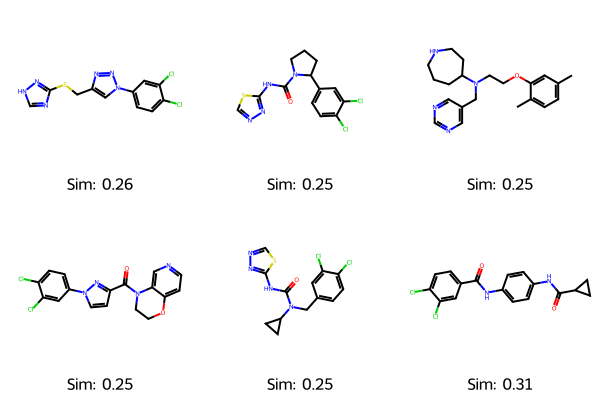

#2: Počet příbuzných molekul je 0.
Není co zobrazit, nejbližších je 0.


#3: Počet příbuzných molekul je 3.


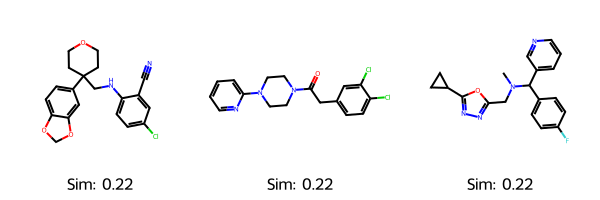

#4: Počet příbuzných molekul je 2.


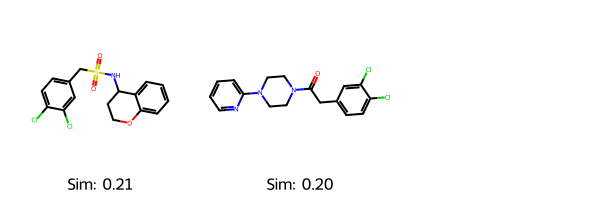

#5: Počet příbuzných molekul je 1.


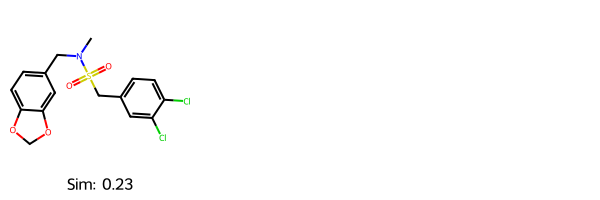

#6: Počet příbuzných molekul je 16.


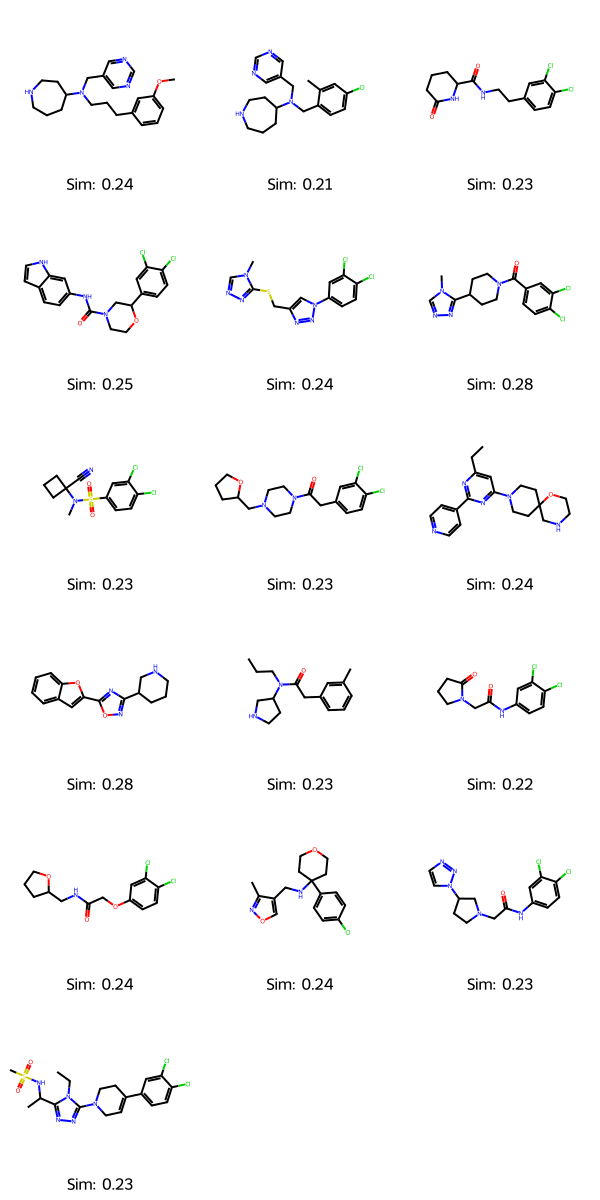

#7: Počet příbuzných molekul je 17.


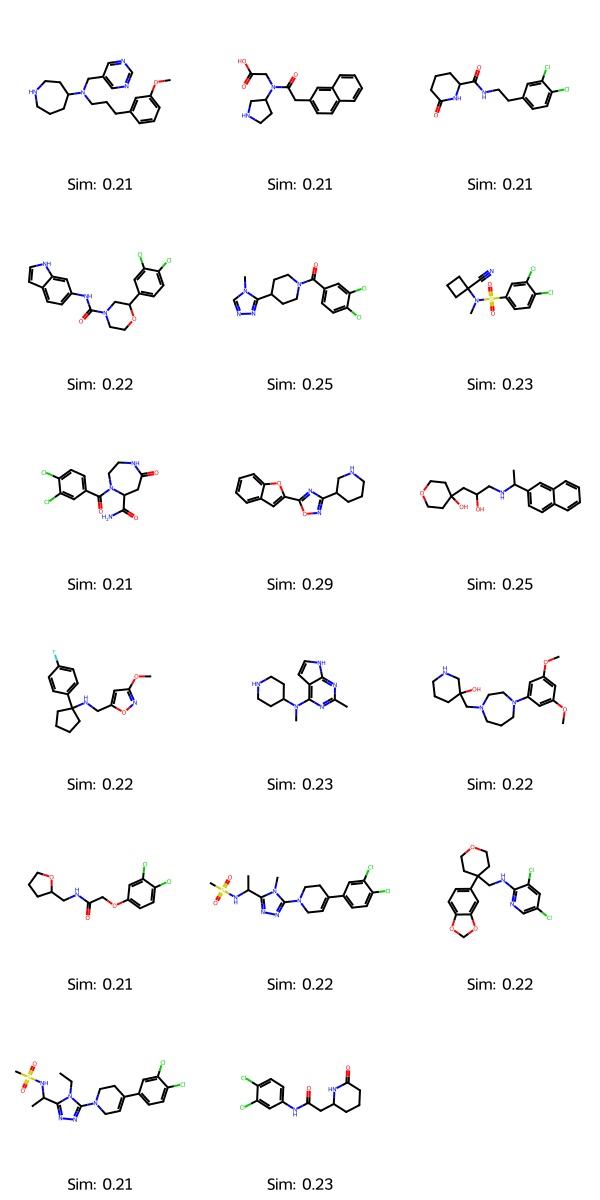

#8: Počet příbuzných molekul je 3.


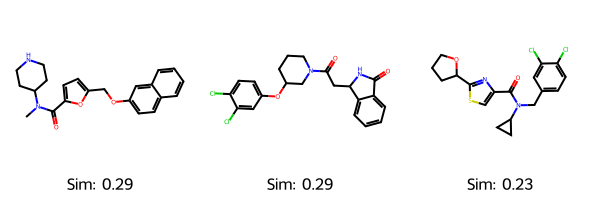

In [104]:
# Projdi top_tagets a najdi podobné k danému léčivu 
for i, i_fp in enumerate(inhibitor_fps): 
    sims = DataStructs.BulkTanimotoSimilarity(i_fp, top_targets_xgb['smiles'].apply(get_fp).tolist())
    
    # Filtruj nad 0.2
    mask = np.array(sims) > 0.2
    similar_local_idx = np.where(mask)[0]
    
    closest_mols = [Chem.MolFromSmiles(top_targets.iloc[idx]['smiles']) for idx in similar_local_idx]
    similar_sims = np.array(sims)[mask]
    print(f"#{i+1}: Počet příbuzných molekul je {sum(mask)}.")
    try:
        display(Draw.MolsToGridImage(closest_mols, legends=[f"Sim: {s:.2f}" for s in similar_sims]))
    except:
        print(f"Není co zobrazit, nejbližších je {len(closest_mols)}.")

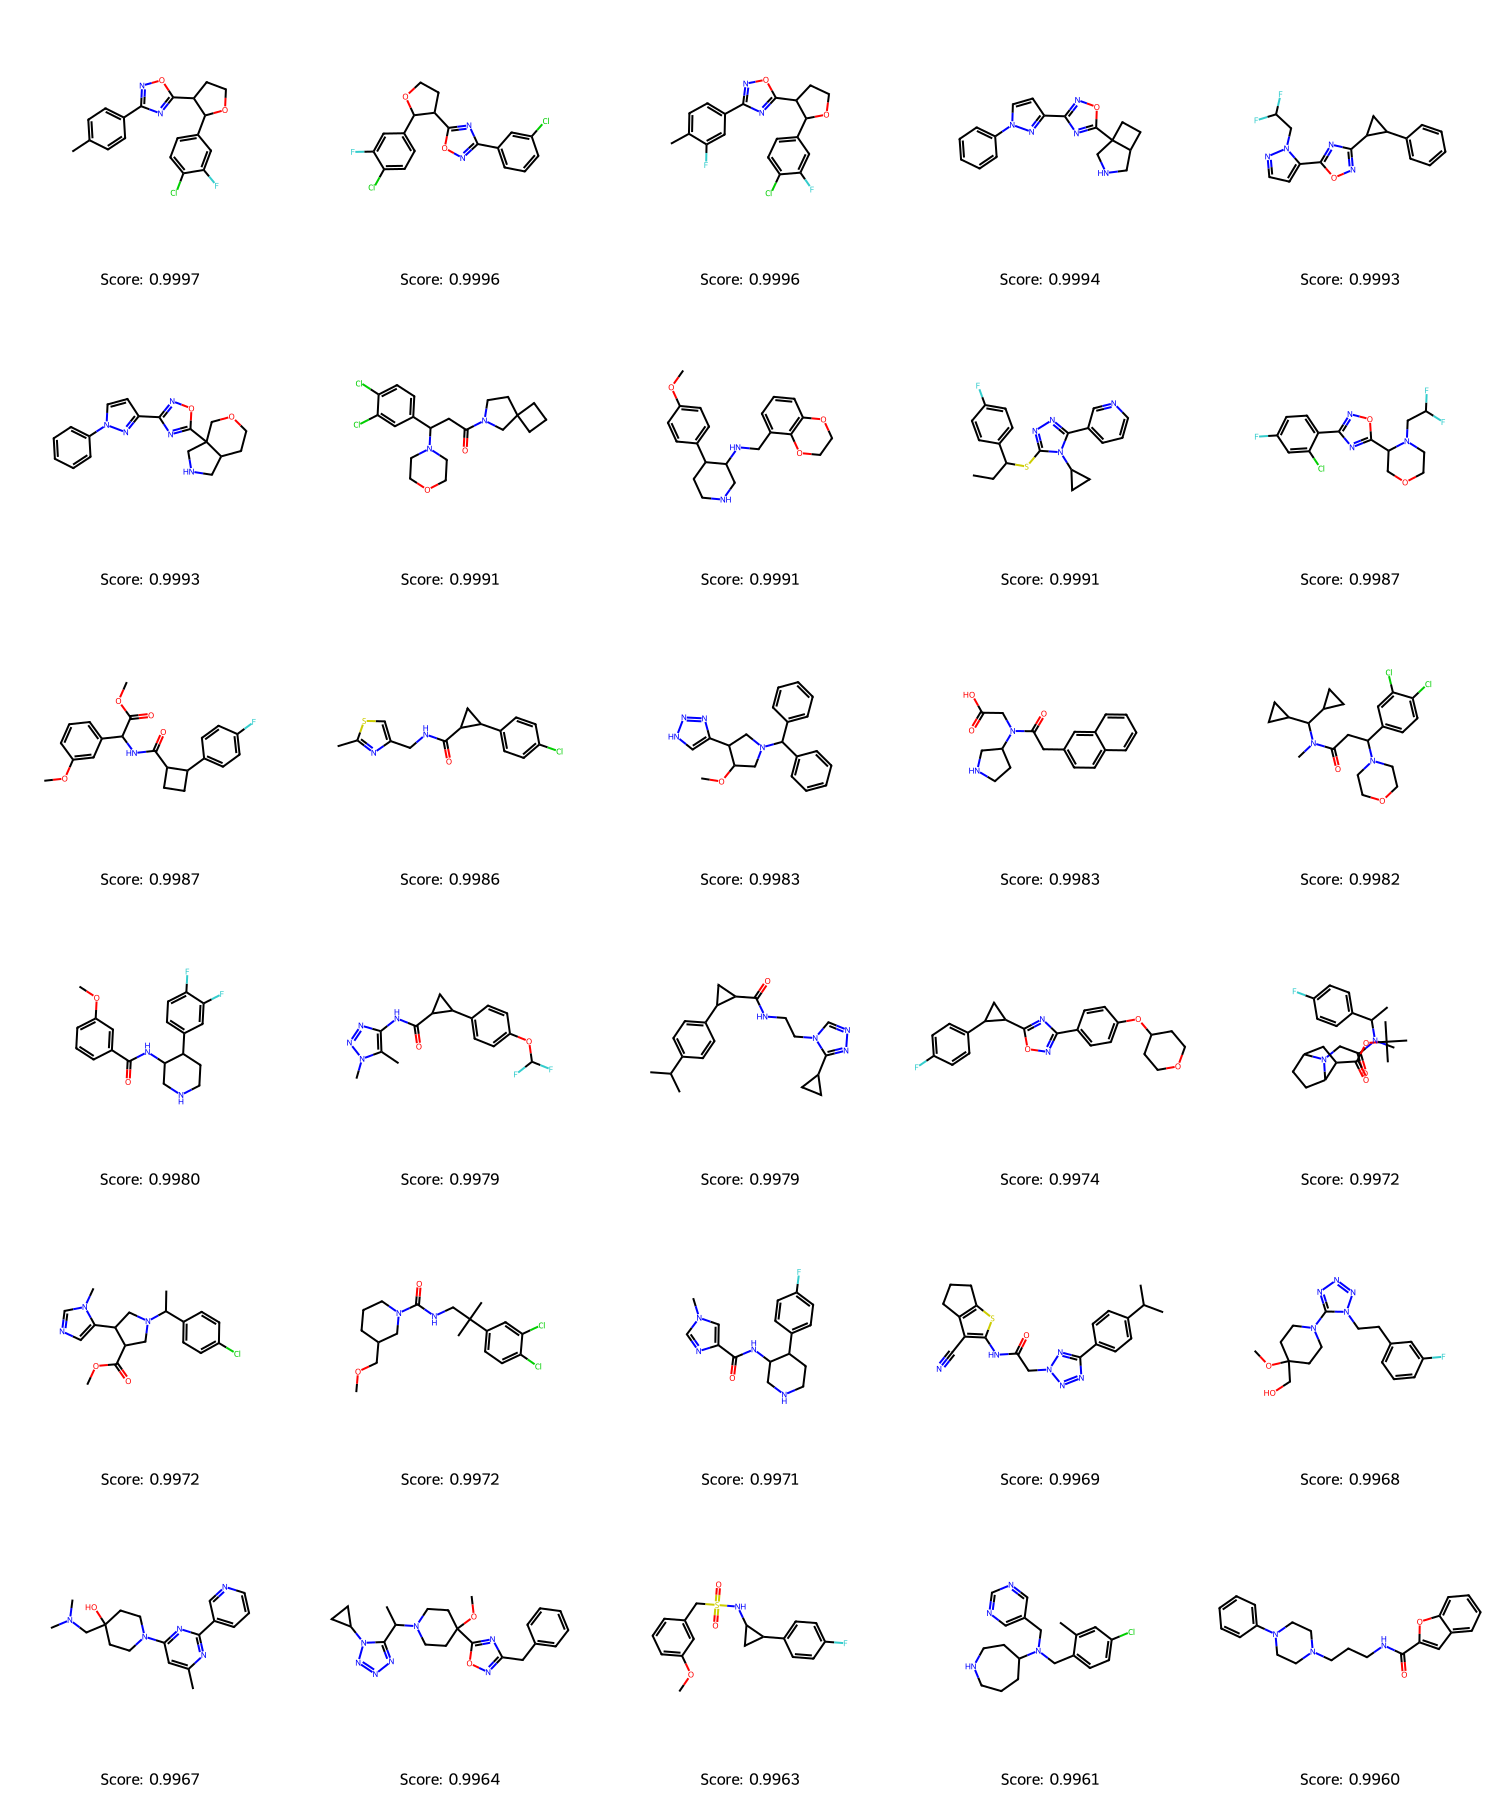

In [106]:
top_30 = top_targets_xgb.sort_values(by='proba', ascending=False).head(30)

mols = [Chem.MolFromSmiles(s) for s in top_30['smiles']]
legends = [f"Score: {p:.4f}" for p in top_30['proba']]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

display(img)

# Finální predikce 
* Chci využít oba modely k nalezení nejlepších látek.
* Nejprve jsem chtěl zkusit průměrovat předpovězenou aktivitu.
* Nicméně, XGBoost a RF mají jinou distribuci prvděpodobností, průměrování nedává smysl. 

In [124]:
# napočítám průměr  
target_result["proba_xgb"] = Y_target_proba_active_xgb
target_result["proba_avg"] = (target_result["proba_xgb"] + target_result["proba"])/2

In [119]:
print(f"xgboost probas: {sum(target_result["proba_xgb"])}")
print(f"rf probas: {sum(target_result["proba"])}")

xgboost probas: 4546.088366836299
rf probas: 11937.90942492983


distribuce xgboost probas


<Axes: xlabel='proba_xgb', ylabel='Density'>

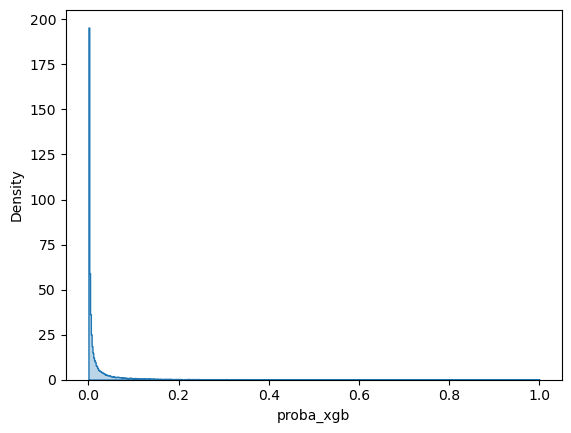

In [146]:
print("distribuce xgboost probas") 
sns.histplot(target_result["proba_xgb"], stat="density", element="step", alpha=0.3)

distribuce rf probas


<Axes: xlabel='proba', ylabel='Density'>

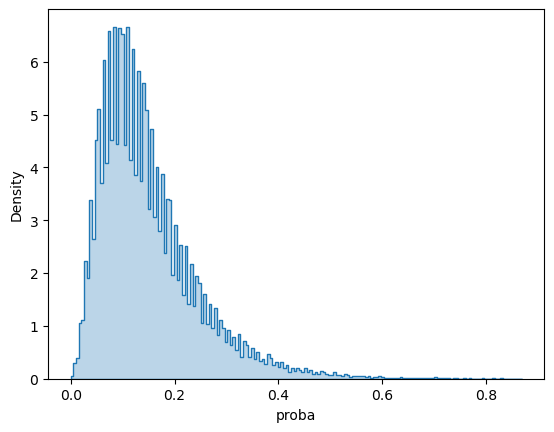

In [147]:
print("distribuce rf probas") 
sns.histplot(target_result["proba"], stat="density", element="step", alpha=0.3)

* Zavedu proto `consensus_rank`, definovaný jako horší z obou ranků. 

In [148]:
# počítám ranky 
target_result['rank_rf'] = target_result['proba'].rank(ascending=False, method='min')
target_result['rank_xgb'] = target_result['proba_xgb'].rank(ascending=False, method='min')

target_result['consensus_rank'] = target_result[['rank_rf', 'rank_xgb']].max(axis=1)

# řazení podle průměrného ranku 
top_consensus = target_result.sort_values(by='consensus_rank').head(25)

In [149]:
top_consensus

,smiles,proba,proba_xgb,proba_avg,rank_rf,rank_xgb,consensus_rank
74461,O=C(CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1)N1CCC2(CCC2)C1,0.828,0.999097,0.913548,2.0,7.0,7.0
47878,O=C(O)CN(C(=O)Cc1ccc2ccccc2c1)C1CCNC1,0.776,0.998270,0.887135,13.0,14.0,14.0
68482,CN(C(=O)CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1)C(C1CC1)C...,0.868,0.998183,0.933092,1.0,15.0,15.0
46097,COCC1CCCN(C(=O)NCC(C)(C)c2ccc(Cl)c(Cl)c2)C1,0.812,0.997167,0.904583,6.0,22.0,22.0
840,Cc1cc(Cl)ccc1CN(Cc1cncnc1)C1CCCNCC1,0.778,0.996124,0.887062,12.0,29.0,29.0
75974,Fc1ccc(C2CC2c2nc(-c3ccc(OC4CCOCC4)cc3)no2)cc1,0.714,0.997441,0.855720,40.0,19.0,40.0
48111,NC(=O)CC(c1ccc(Cl)c(Cl)c1)N1CCOCC1,0.814,0.994948,0.904474,4.0,40.0,40.0
11903,CC(c1ccc(F)cc1)N(C)C(=O)CN1C2CCC1C(C(=O)OC(C)(...,0.714,0.997241,0.855620,40.0,20.0,40.0
37749,N#Cc1ccc(Cl)cc1NCC1(c2ccc3c(c2)OCO3)CCOCC1,0.706,0.995188,0.850594,45.0,36.0,45.0
554,Cc1ccc(-c2noc(C3CCOC3c3ccc(Cl)c(F)c3)n2)cc1,0.706,0.999715,0.852858,45.0,1.0,45.0


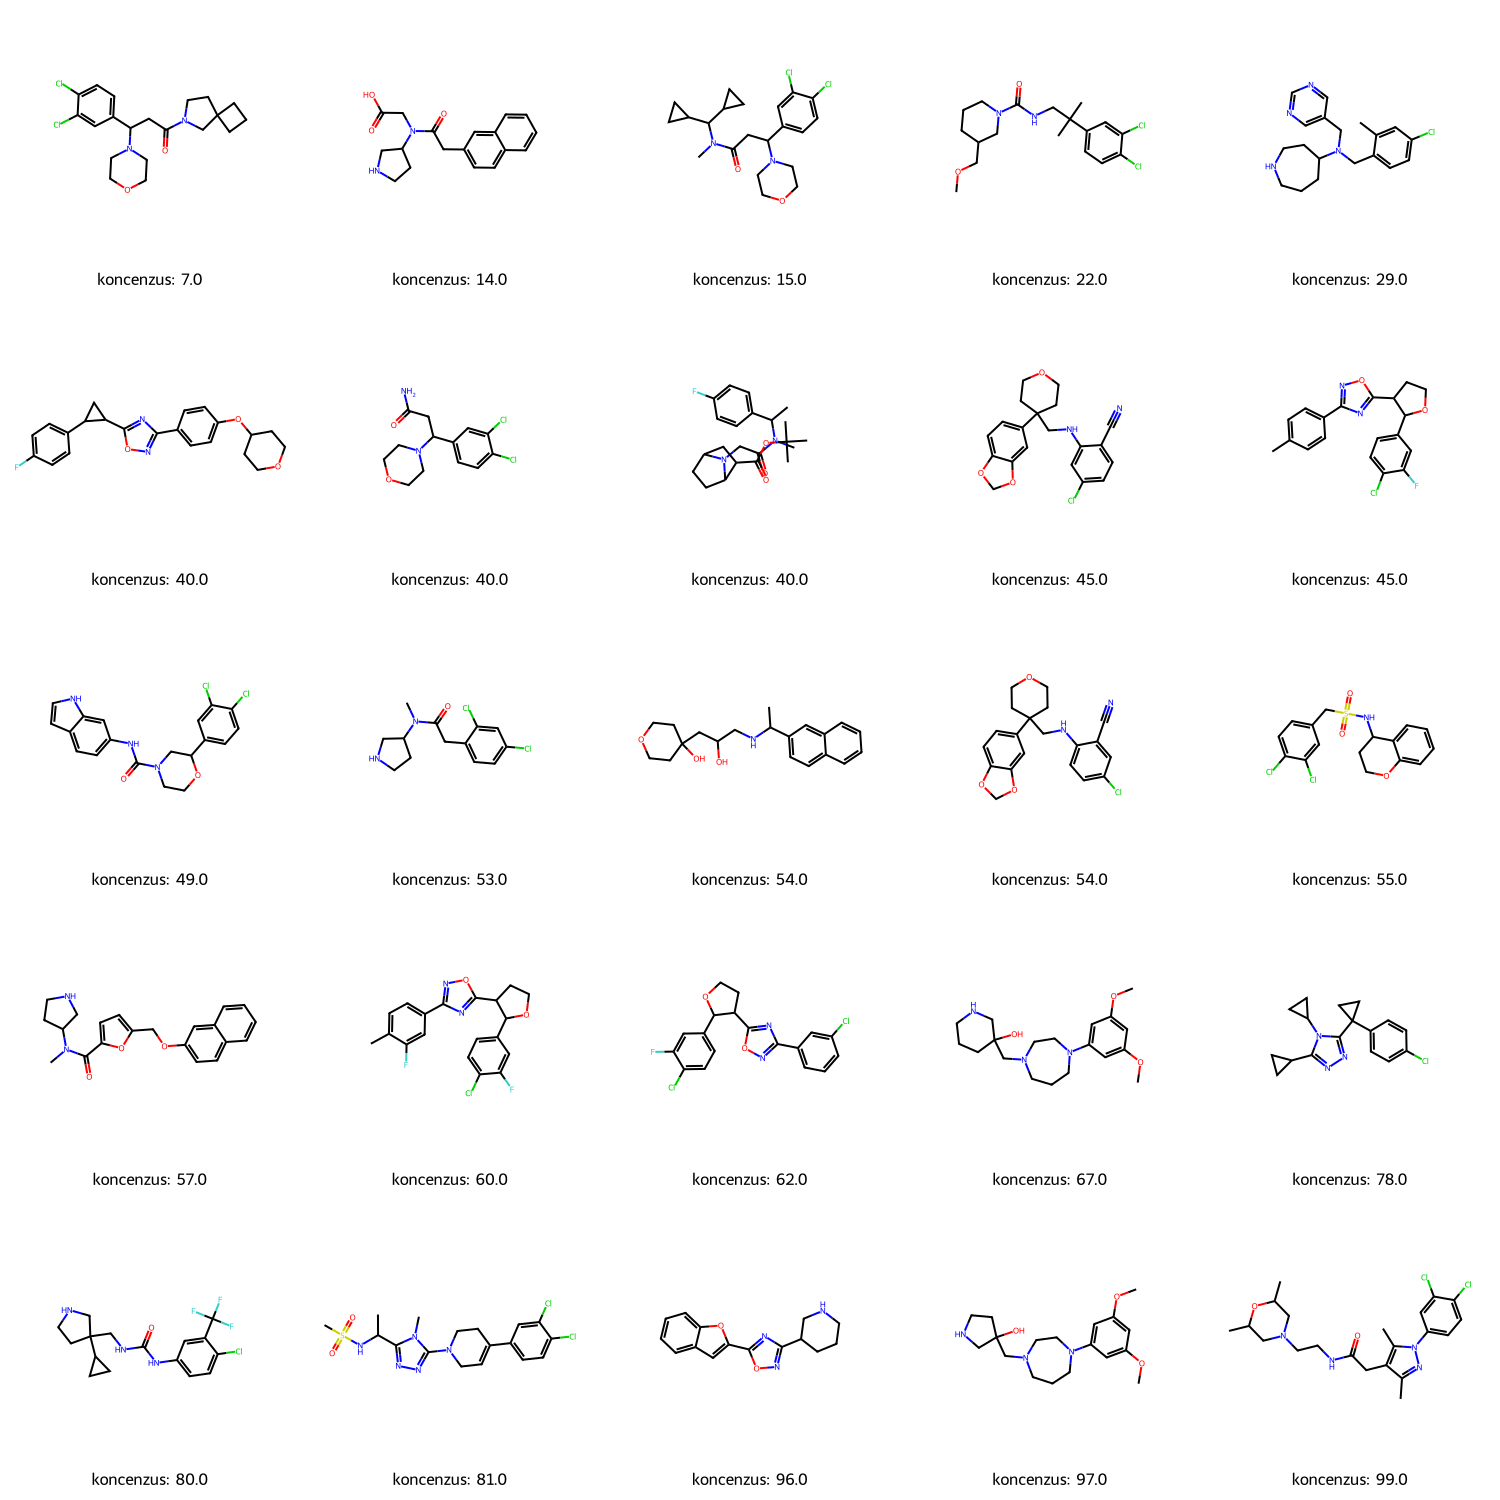

In [189]:
mols = [Chem.MolFromSmiles(s) for s in top_consensus['smiles']]
legends = [f"koncenzus: {p}" for p in top_consensus['consensus_rank']]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

display(img)

# Závěr 
Cílem mojí práce bylo najít nové inhibitory DAT. Svého cíle jsem dosáhl v následujících krocích:
* Na základě databáze schálených léčiv z BrugBank jsem sestavil set látek, které jako inhibitory DAT nefungují. Pokud by látky tyto účinky měly, nebyly by schváleny jako léčiva. 
* Na základě Chembl jsem sestavil set inhibitorů DAT.
* Z Enamine jsem získal set cílových látek, vybral jsem látky s Tanimotovou podobností k trénovacímu setu vyšší než 0.25.
* Natrénoval jsem dva modely, Random Forrest a XGBoost.
    * Random Forrest dosáhl na 5-fold crossvalidaci AUC-PR (Area Under the Precision-Recall Curve) 98.69 %, na testovacích datech dosáhl recall = 0.629 a enrichment faktor = 6.914.
    * XGBoost dosáhl při stejné evaluaci AUC-PR = 0.9863 a totožných hodnot recall a enrichment faktoru.
* Koncenzuálním rozhodnutím obou modelů jsem vybral 25 molekul s nejpravděpodobnější aktivitou.  